# 05 - Evaluation: Experimental Schemas Comparison - Presentation Slides

## Import libraries and set the paths

In [1]:
from __future__ import annotations

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


import networkx as nx
import scikit_posthocs as sp

from myocardial_infarction_mortality.config import MODELS_DIR, FIGURES_DIR
from myocardial_infarction_mortality.evaluation.statistical_test_evaluation import corrected_resampled_ttest

2026-04-21 13:28:49.594 | INFO     | myocardial_infarction_mortality.config:<module>:16 - PROJ_ROOT path is: D:\2_UNIVERSITA\2_MAGISTRALE\1_ANNO\6_MACHINE_LEARNING\2-2023-2024\4-PROJECT\Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction


In [2]:
EXPERIMENTS_NAME = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
}

In [3]:
FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR = FIGURES_DIR / "EV_experimental_schemas_comparison_presentation"
FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
pd.set_option("display.max_columns", None)
plt.rcParams.update({"font.size": 16})
sns.set_style("whitegrid")
sns.set_palette("tab10")

## Data Loading and Basic Overview

In [5]:
all_frames = []

print(f"{'='*80}\nLOADING EXPERIMENTAL SCHEMAS\n{'='*80}")

for folder_name, schema_label in EXPERIMENTS_NAME.items():
    experiment_path = MODELS_DIR / folder_name

    # 1. Verify Folder Exists
    if not experiment_path.exists():
        print(f"[WARNING] Experiment folder not found: {folder_name}")
        continue

    # 2. Find Results Files (Recursively)
    # Looking for 'generalization_metrics_summary.csv' inside any model subfolder
    files = list(experiment_path.glob("**/generalization_metrics_summary.csv"))

    if not files:
        print(f"[SKIP] No results files found for schema: {schema_label}")
        continue

    print(f"Loading '{schema_label}' ({len(files)} files found)...")

    # 3. Load and Process Each File
    for f in files:
        try:
            df_temp = pd.read_csv(f)

            # A. Rename original 'model' to 'model_no_alias'
            df_temp.rename(columns={"model": "model_no_alias"}, inplace=True)

            # B. Create the NEW 'model' column (Concatenation)
            # Format: "ModelName (Alias)" -> e.g. "XGBoost (Cost-Sensitive)"
            df_temp["model"] = df_temp["model_no_alias"] + " (" + schema_label + ")"

            # C. Maintain experiment_name (Explicit check, though likely present)
            # If the CSV didn't have it, we could infer it from folder_name,
            # but usually it is already in the results file.
            if "experiment_name" not in df_temp.columns:
                df_temp["experiment_name"] = folder_name

            # D. Track schema label explicitly (optional, but good for filtering)
            df_temp["learning_schema"] = schema_label

            all_frames.append(df_temp)

        except Exception as e:
            print(f"  [ERROR] Could not read file {f.name}: {e}")

# --- 4. CONCATENATE MASTER DATAFRAME ---
generalization_df = pd.DataFrame()
if all_frames:
    generalization_df = pd.concat(all_frames, ignore_index=True)

    print("\n" + "="*80)
    print("SUCCESS: MASTER DATAFRAME CREATED")
    print("="*80)
    print(f"Total Evaluation Rows Loaded: {len(generalization_df)}")
    print(f"Total Unique Models (Tagged): {generalization_df['model'].nunique()}")

    # Validation: Preview the specific columns we modified
    print("\nPreview of Key Columns:")
    print(generalization_df[["experiment_name", "model_no_alias", "model"]].head())

else:
    print("\n[ERROR] No data loaded. Please check your MODELS_DIR path and folder names.")

LOADING EXPERIMENTAL SCHEMAS
Loading 'Baseline' (12 files found)...
Loading 'Balanced + STD' (12 files found)...
Loading 'Cost-sensitive + STD' (12 files found)...
Loading 'SMOTE + STD' (12 files found)...
Loading 'Balanced + MEC' (12 files found)...
Loading 'Cost-sensitive + MEC' (12 files found)...
Loading 'SMOTE + MEC' (12 files found)...

SUCCESS: MASTER DATAFRAME CREATED
Total Evaluation Rows Loaded: 8400
Total Unique Models (Tagged): 84

Preview of Key Columns:
      experiment_name          model_no_alias  \
0  baseline__standard  DecisionTreeClassifier   
1  baseline__standard  DecisionTreeClassifier   
2  baseline__standard  DecisionTreeClassifier   
3  baseline__standard  DecisionTreeClassifier   
4  baseline__standard  DecisionTreeClassifier   

                               model  
0  DecisionTreeClassifier (Baseline)  
1  DecisionTreeClassifier (Baseline)  
2  DecisionTreeClassifier (Baseline)  
3  DecisionTreeClassifier (Baseline)  
4  DecisionTreeClassifier (Baseline)  

In [6]:
generalization_df

,experiment_name,iteration,fold,model_no_alias,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,average_cost,score_time,fold_size,selected_features_names,model,learning_schema
0,baseline__standard,1,1,DecisionTreeClassifier,generalization,4,131,2,21,0.854430,0.666667,0.160000,0.258065,0.984962,0.015038,0.572481,0.396981,0.276792,0.209656,0.572481,0.239578,1.341772,0.046126,158,"['num_log1p_standard_scaler__L_BLOOD', 'num_st...",DecisionTreeClassifier (Baseline),Baseline
1,baseline__standard,1,2,DecisionTreeClassifier,generalization,7,131,1,19,0.873418,0.875000,0.269231,0.411765,0.992424,0.007576,0.630828,0.516905,0.442499,0.362389,0.674971,0.397733,1.208861,0.044497,158,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DecisionTreeClassifier (Baseline),Baseline
2,baseline__standard,1,3,DecisionTreeClassifier,generalization,4,129,3,21,0.847134,0.571429,0.160000,0.250000,0.977273,0.022727,0.568636,0.395428,0.243359,0.193838,0.633182,0.250008,1.356688,0.043970,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_st...",DecisionTreeClassifier (Baseline),Baseline
3,baseline__standard,1,4,DecisionTreeClassifier,generalization,3,129,3,22,0.840764,0.500000,0.120000,0.193548,0.977273,0.022727,0.548636,0.342451,0.185645,0.140574,0.696970,0.307331,1.420382,0.043974,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DecisionTreeClassifier (Baseline),Baseline
4,baseline__standard,1,5,DecisionTreeClassifier,generalization,5,132,0,20,0.872611,1.000000,0.200000,0.333333,1.000000,0.000000,0.600000,0.447214,0.416754,0.295964,0.649545,0.361593,1.273885,0.044501,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DecisionTreeClassifier (Baseline),Baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,smote_auto__mec_fp1_fn10,10,6,XGBClassifier,generalization,24,77,55,1,0.643312,0.303797,0.960000,0.461538,0.583333,0.416667,0.771667,0.748331,0.397615,0.289708,0.904848,0.658034,0.414013,0.025432,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8396,smote_auto__mec_fp1_fn10,10,7,XGBClassifier,generalization,25,11,121,0,0.229299,0.171233,1.000000,0.292398,0.083333,0.916667,0.541667,0.288675,0.119455,0.028137,0.675606,0.303010,0.770701,0.022729,157,"['num_standard_scaler__AGE', 'num_standard_sca...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8397,smote_auto__mec_fp1_fn10,10,8,XGBClassifier,generalization,24,32,100,1,0.356688,0.193548,0.960000,0.322148,0.242424,0.757576,0.601212,0.482418,0.181782,0.077706,0.733939,0.461629,0.700637,0.022903,157,"['num_standard_scaler__AGE', 'num_standard_sca...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8398,smote_auto__mec_fp1_fn10,10,9,XGBClassifier,generalization,24,82,50,1,0.675159,0.324324,0.960000,0.484848,0.621212,0.378788,0.790606,0.772246,0.426027,0.323904,0.898788,0.706325,0.382166,0.025208,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",XGBClassifier (SMOTE + MEC),SMOTE + MEC


In [7]:
models_to_analyze = ["LogisticRegression",
                     "RandomForestClassifier",
                     "XGBClassifier",
                     "VotingClassifier",
                     "StackingClassifier",
                     "KNORAE",
                     "DESKL",
                     "METADES",
                     ]
print(f"Selected models:\n\t{models_to_analyze}")

generalization_df = generalization_df[generalization_df["model_no_alias"].isin(models_to_analyze)]
generalization_df

Selected models:
	['LogisticRegression', 'RandomForestClassifier', 'XGBClassifier', 'VotingClassifier', 'StackingClassifier', 'KNORAE', 'DESKL', 'METADES']


,experiment_name,iteration,fold,model_no_alias,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,average_cost,score_time,fold_size,selected_features_names,model,learning_schema
100,baseline__standard,1,1,DESKL,generalization,3,132,1,22,0.854430,0.750000,0.120000,0.206897,0.992481,0.007519,0.556241,0.345105,0.261328,0.170698,0.764812,0.414571,1.398734,0.250332,158,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DESKL (Baseline),Baseline
101,baseline__standard,1,2,DESKL,generalization,8,131,1,18,0.879747,0.888889,0.307692,0.457143,0.992424,0.007576,0.650058,0.552595,0.480119,0.406954,0.796329,0.600120,1.145570,0.166502,158,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DESKL (Baseline),Baseline
102,baseline__standard,1,3,DESKL,generalization,3,132,0,22,0.859873,1.000000,0.120000,0.214286,1.000000,0.000000,0.560000,0.346410,0.320713,0.186528,0.871212,0.580750,1.401274,0.148144,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DESKL (Baseline),Baseline
103,baseline__standard,1,4,DESKL,generalization,0,130,2,25,0.828025,0.000000,0.000000,0.000000,0.984848,0.015152,0.492424,0.000000,-0.049435,-0.024160,0.873030,0.518707,1.605096,0.224802,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",DESKL (Baseline),Baseline
104,baseline__standard,1,5,DESKL,generalization,5,132,0,20,0.872611,1.000000,0.200000,0.333333,1.000000,0.000000,0.600000,0.447214,0.416754,0.295964,0.779697,0.586524,1.273885,0.099766,157,"['num_standard_scaler__AGE', 'num_standard_sca...",DESKL (Baseline),Baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,smote_auto__mec_fp1_fn10,10,6,XGBClassifier,generalization,24,77,55,1,0.643312,0.303797,0.960000,0.461538,0.583333,0.416667,0.771667,0.748331,0.397615,0.289708,0.904848,0.658034,0.414013,0.025432,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8396,smote_auto__mec_fp1_fn10,10,7,XGBClassifier,generalization,25,11,121,0,0.229299,0.171233,1.000000,0.292398,0.083333,0.916667,0.541667,0.288675,0.119455,0.028137,0.675606,0.303010,0.770701,0.022729,157,"['num_standard_scaler__AGE', 'num_standard_sca...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8397,smote_auto__mec_fp1_fn10,10,8,XGBClassifier,generalization,24,32,100,1,0.356688,0.193548,0.960000,0.322148,0.242424,0.757576,0.601212,0.482418,0.181782,0.077706,0.733939,0.461629,0.700637,0.022903,157,"['num_standard_scaler__AGE', 'num_standard_sca...",XGBClassifier (SMOTE + MEC),SMOTE + MEC
8398,smote_auto__mec_fp1_fn10,10,9,XGBClassifier,generalization,24,82,50,1,0.675159,0.324324,0.960000,0.484848,0.621212,0.378788,0.790606,0.772246,0.426027,0.323904,0.898788,0.706325,0.382166,0.025208,157,"['num_log1p_standard_scaler__L_BLOOD', 'num_lo...",XGBClassifier (SMOTE + MEC),SMOTE + MEC


## Slide 1 - Baseline vs Standard Threshold Approach: F1-score / Precision / Recall / Average Cost

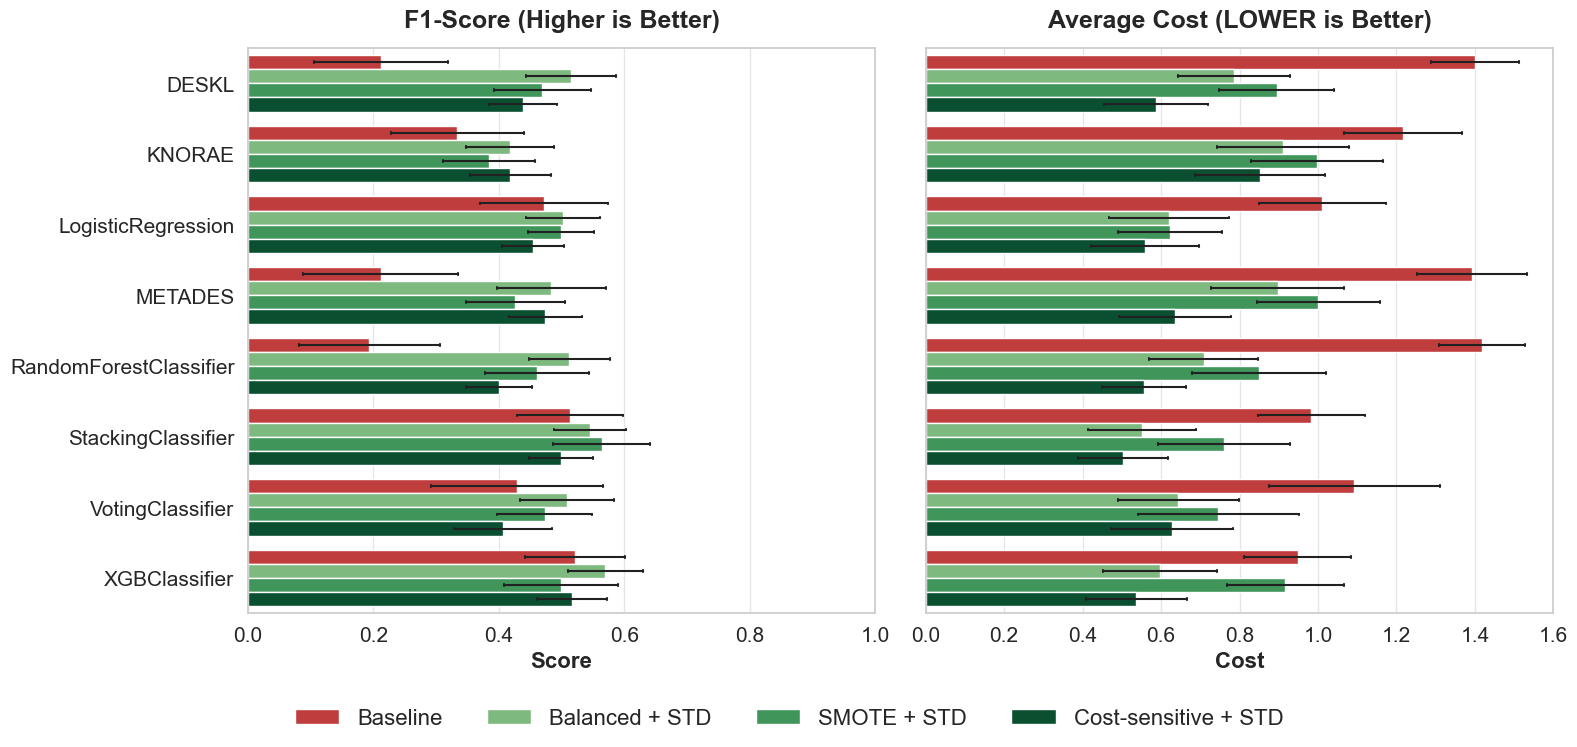

In [8]:
# Select the experiment to compare
experiments_mapping = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD"
}

# Filter and sort the dataframe
df_slide1 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping.keys())].copy()
df_slide1["experiment_name"] = pd.Categorical(
    df_slide1["experiment_name"].map(experiments_mapping),
    categories=list(experiments_mapping.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), sharey=True)

metrics = ["f1", "average_cost"]
titles = [
    "F1-Score (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
colors = ["#d62728", "#74c476", "#31a354", "#005a32"]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide1,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors,
        errorbar="sd",
        capsize=0.1,
        err_kws={"linewidth": 1.5, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric == "f1" else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    if metric == "f1":
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout(rect=[0, 0.12, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=16,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide1_baseline_std_settings_f1_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

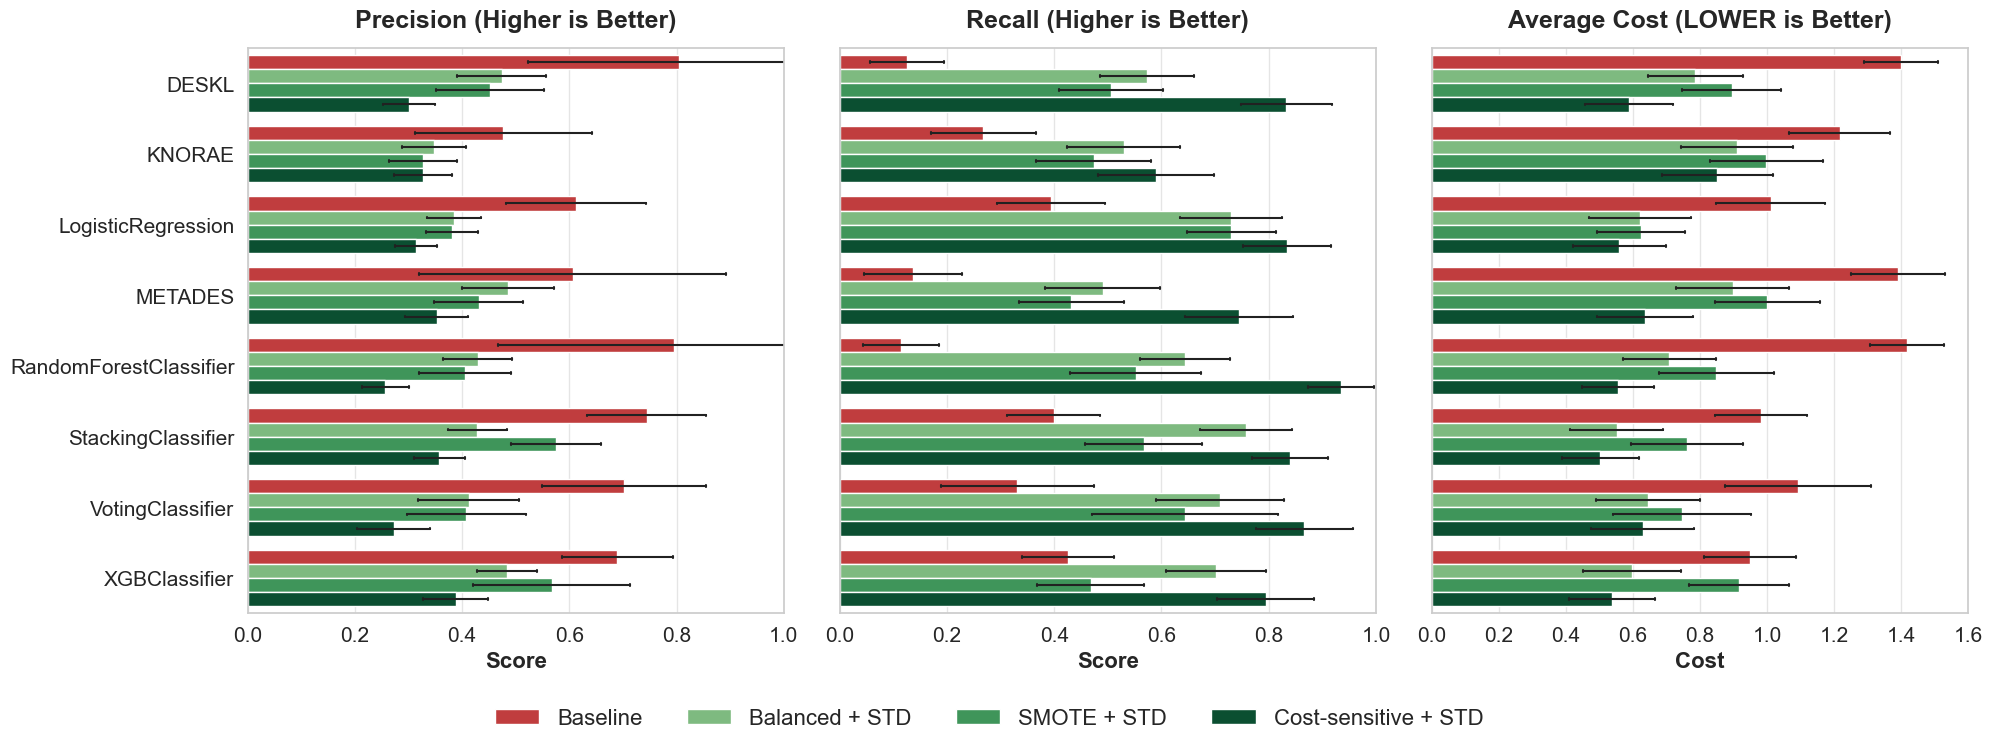

In [9]:
# Select the experiment to compare
experiments_mapping = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD"
}

# Filter and sort the dataframe
df_slide1 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping.keys())].copy()
df_slide1["experiment_name"] = pd.Categorical(
    df_slide1["experiment_name"].map(experiments_mapping),
    categories=list(experiments_mapping.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8), sharey=True)

# Added "f1" to metrics and corresponding title
metrics = ["precision", "recall", "average_cost"]
titles = [
    "Precision (Higher is Better)",
    "Recall (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
colors = ["#d62728", "#74c476", "#31a354", "#005a32"]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide1,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors,
        errorbar="sd",
        capsize=0.1,
        err_kws={"linewidth": 1.5, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)

    axes[i].set_xlabel("Score" if metric in ["precision", "recall"] else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    if metric in ["precision", "recall"]:
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)


    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout(rect=[0, 0.12, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=16,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide1_baseline_std_settings_precision_recall_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

## Slide 2 - Baseline vs MEC Threshold Approach: F1-score / Precision / Recall / Average Cost

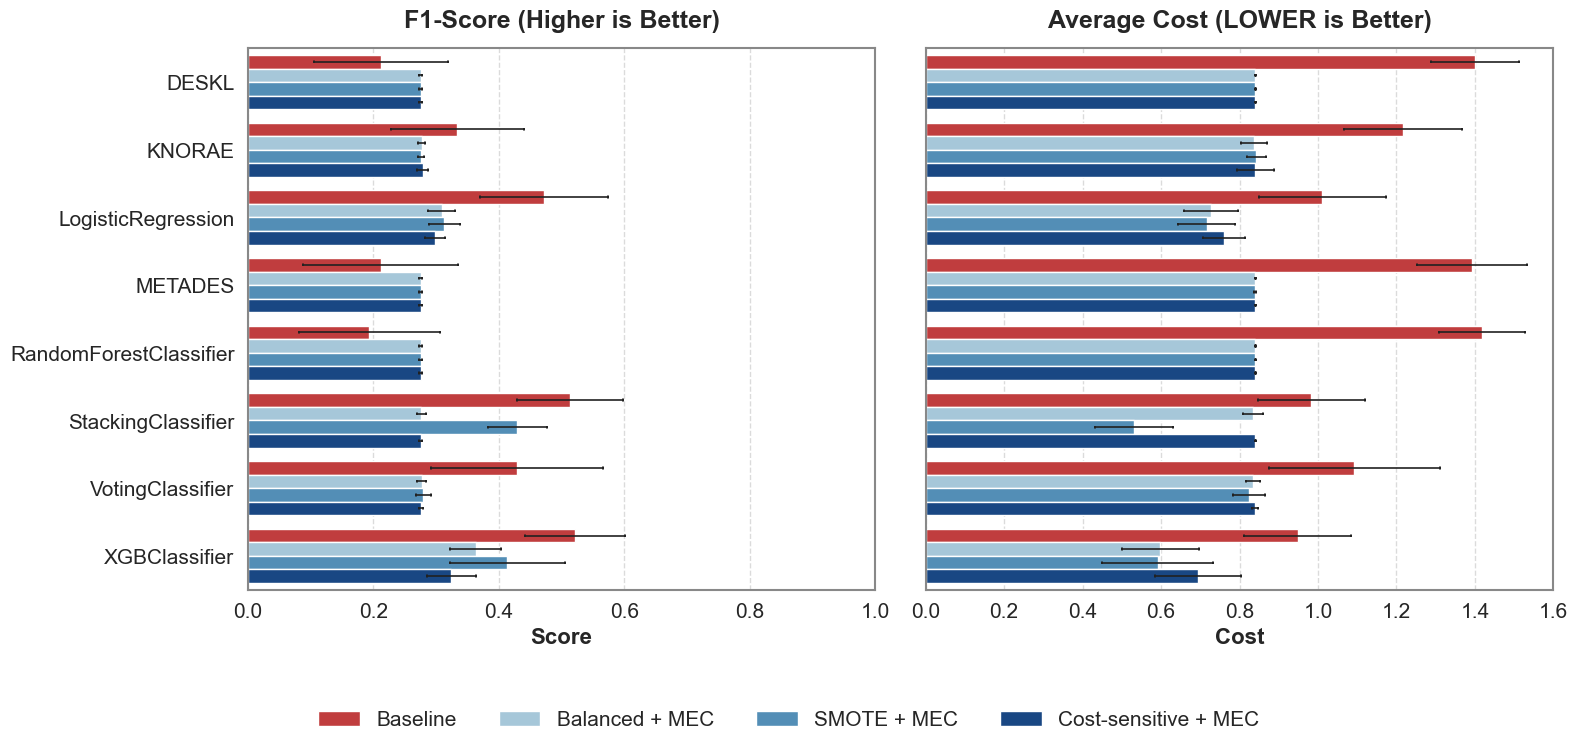

In [10]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide2 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide2["experiment_name"] = pd.Categorical(
    df_slide2["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), sharey=True)

metrics = ["f1", "average_cost"]
titles = [
    "F1-Score (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#9ecae1", "#4292c6", "#084594"
]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide2,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors_all,
        errorbar="sd",
        capsize=0.08,
        err_kws={"linewidth": 1.2, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric == "f1" else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    axes[i].yaxis.grid(False)
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

    if metric == "f1":
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()


plt.tight_layout(rect=[0, 0.15, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))


plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide2_baseline_mec_settings_f1_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

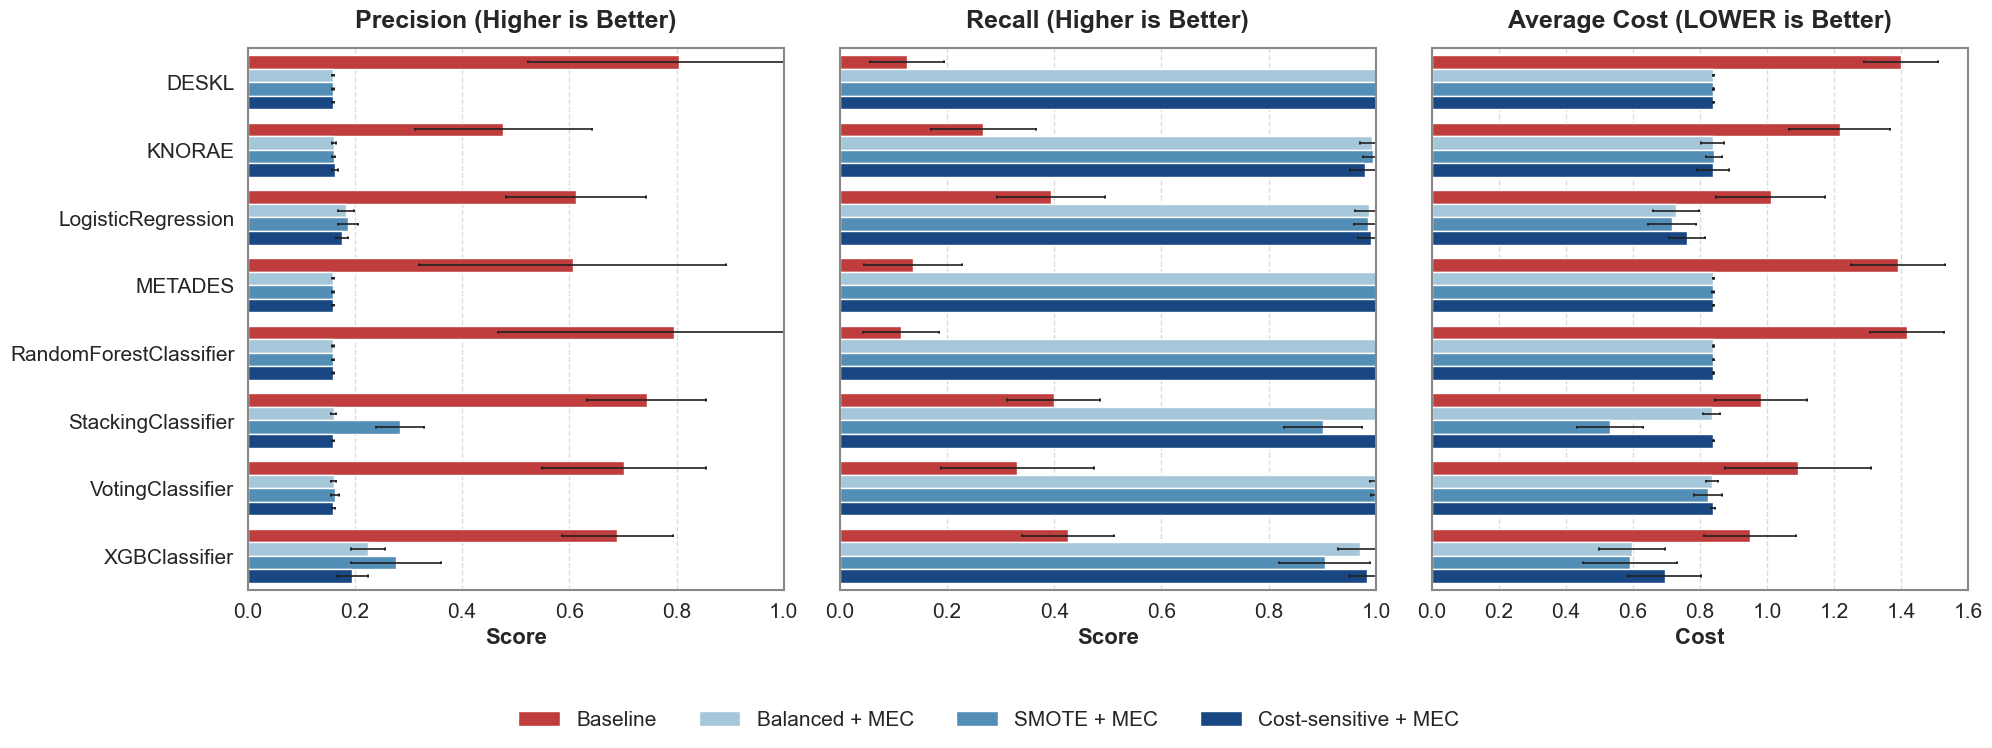

In [11]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide2 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide2["experiment_name"] = pd.Categorical(
    df_slide2["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8), sharey=True)

# Fix the metrics
metrics = ["precision", "recall", "average_cost"]
titles = [
    "Precision (Higher is Better)",
    "Recall (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#9ecae1", "#4292c6", "#084594"
]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide2,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors_all,
        errorbar="sd",
        capsize=0.08,
        err_kws={"linewidth": 1.2, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric in ["precision", "recall"] else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    axes[i].yaxis.grid(False)
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

    if metric in ["precision", "recall"]:
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout(rect=[0, 0.15, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide2_baseline_mec_settings_precision_recall_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

## Slide 3 - All Experimental Approaches: F1-score / Precision / Recall / Average Cost

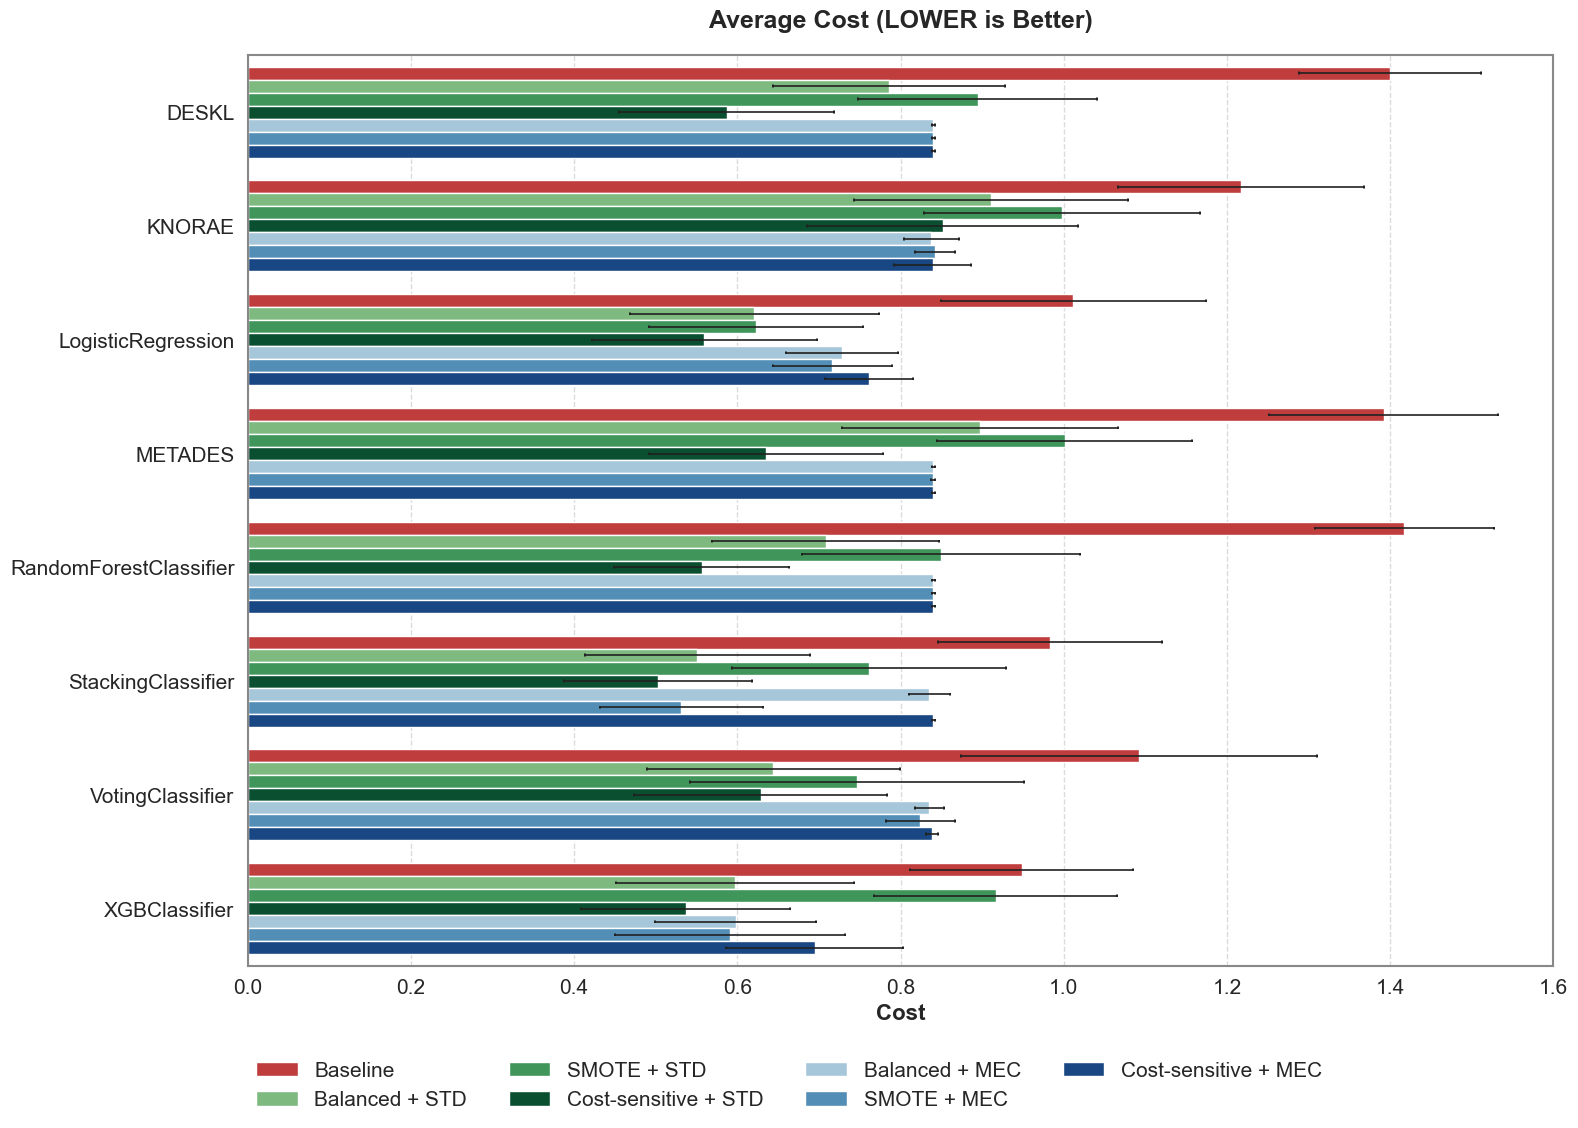

In [12]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide3 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide3["experiment_name"] = pd.Categorical(
    df_slide3["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, ax = plt.subplots(figsize=(16, 12))

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#74c476", "#31a354", "#005a32",
    "#9ecae1", "#4292c6", "#084594"
]

sns.barplot(
    data=df_slide3,
    x="average_cost",
    y="model_no_alias",
    hue="experiment_name",
    ax=ax,
    palette=colors_all,
    errorbar="sd",
    capsize=0.08,
    err_kws={"linewidth": 1.2, "color": "#212121"}
)

ax.set_title("Average Cost (LOWER is Better)", fontweight="bold", pad=20)
ax.set_xlabel("Cost", fontweight="bold")
ax.set_ylabel('')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#888888')
    spine.set_linewidth(1.5)

ax.yaxis.grid(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_xlim(0, 1.6)

if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.tight_layout(rect=[0, 0.12, 1, 1])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide3_all_settings_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

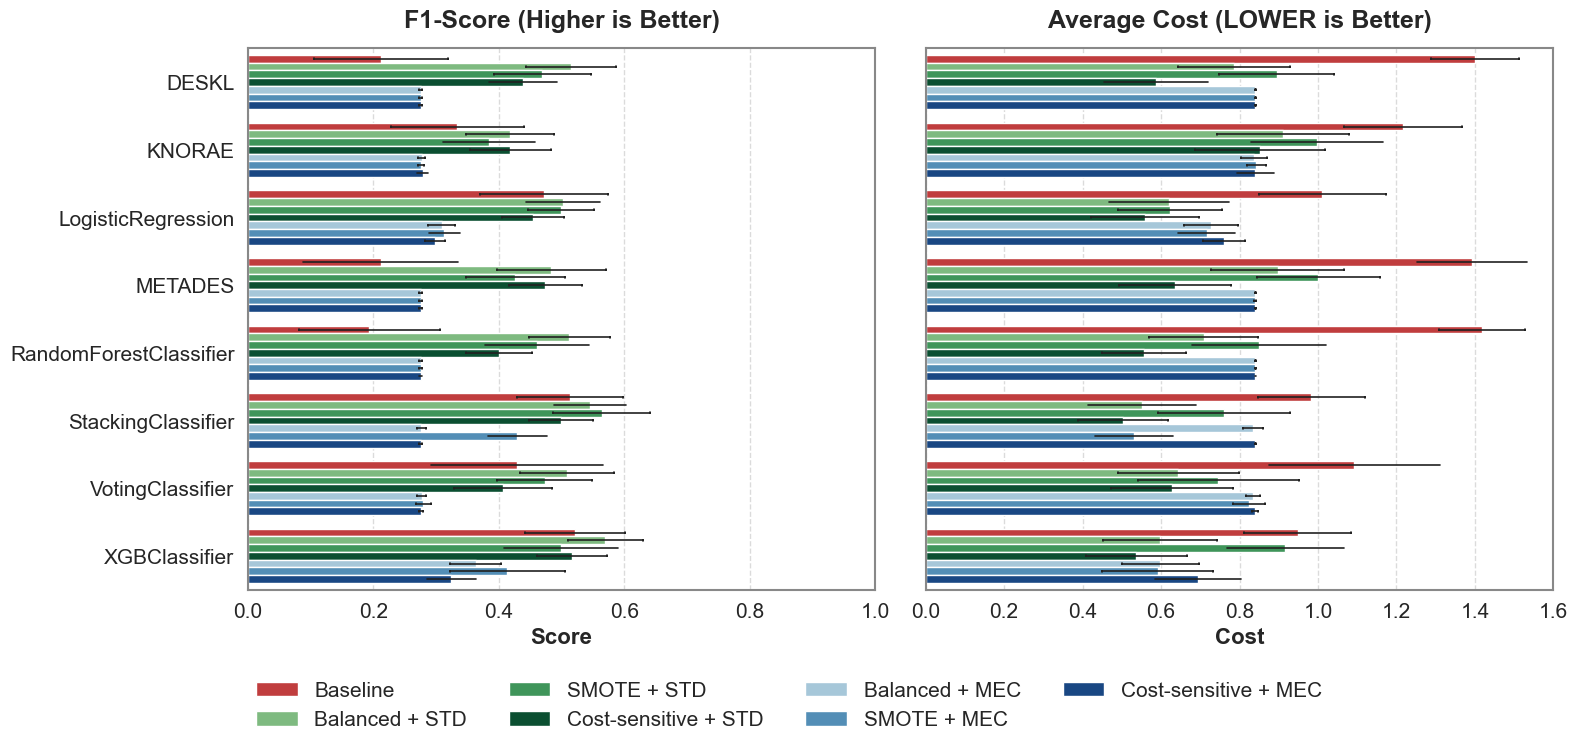

In [13]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide3 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide3["experiment_name"] = pd.Categorical(
    df_slide3["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), sharey=True)

metrics = ["f1", "average_cost"]
titles = [
    "F1-Score (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#74c476", "#31a354", "#005a32",
    "#9ecae1", "#4292c6", "#084594"
]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide3,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors_all,
        errorbar="sd",
        capsize=0.08,
        err_kws={"linewidth": 1.2, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric == "f1" else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    axes[i].yaxis.grid(False)
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

    if metric == "f1":
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()


plt.tight_layout(rect=[0, 0.15, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))


plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide3_all_settings_f1_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

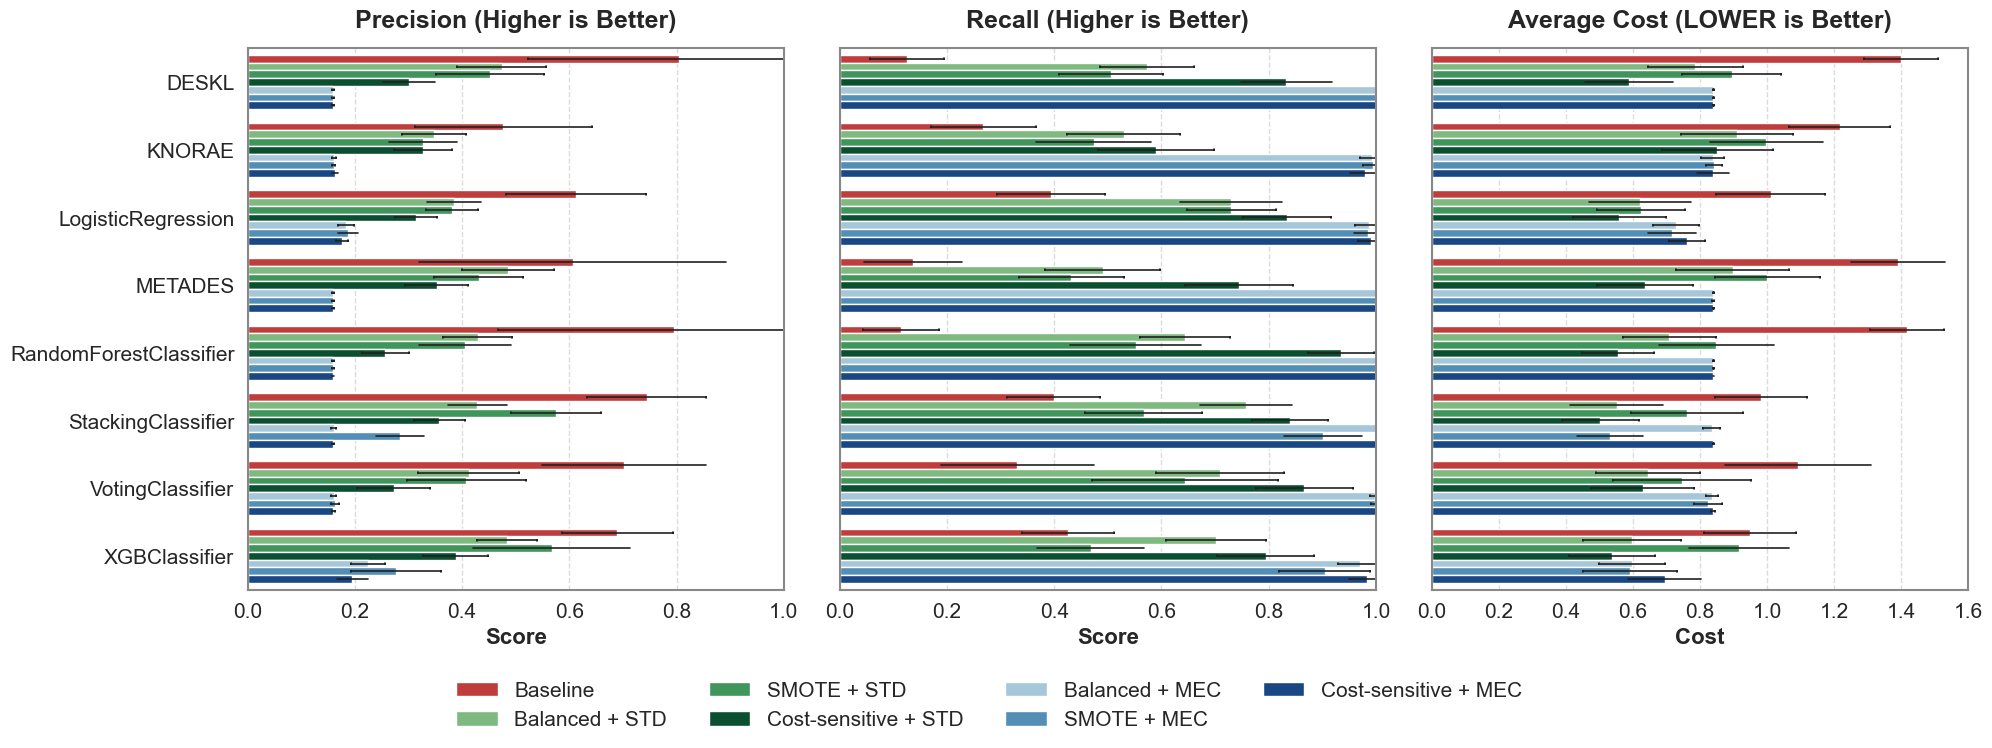

In [14]:
# Select the experiment to compare
experiments_mapping_all = {
    "baseline__standard": "Baseline",
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD",
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide3 = generalization_df[generalization_df["experiment_name"].isin(experiments_mapping_all.keys())].copy()
df_slide3["experiment_name"] = pd.Categorical(
    df_slide3["experiment_name"].map(experiments_mapping_all),
    categories=list(experiments_mapping_all.values()),
    ordered=True
)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8), sharey=True)

# Fix the metrics
metrics = ["precision", "recall", "average_cost"]
titles = [
    "Precision (Higher is Better)",
    "Recall (Higher is Better)",
    "Average Cost (LOWER is Better)"
]

# Fix the palette
# d62728: Red           -> baseline
# 74c476: Light Green   -> balanced + STD
# 31a354: Medium Green  -> SMOTE + STD
# 005a32: Dark Green    -> Cost Sens + STD
# 9ecae1: Light Blue    -> balanced + MEC
# 4292c6: Medium Blue   -> SMOTE + MEC
# 084594: Dark Blue     -> Cost Sens + MEC
colors_all = [
    "#d62728",
    "#74c476", "#31a354", "#005a32",
    "#9ecae1", "#4292c6", "#084594"
]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_slide3,
        x=metric,
        y="model_no_alias",
        hue="experiment_name",
        ax=axes[i],
        palette=colors_all,
        errorbar="sd",
        capsize=0.08,
        err_kws={"linewidth": 1.2, "color": "#212121"}
    )

    axes[i].set_title(titles[i], fontweight="bold", pad=15)
    axes[i].set_xlabel("Score" if metric in ["precision", "recall"] else "Cost", fontweight="bold")
    axes[i].set_ylabel('')

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    axes[i].yaxis.grid(False)
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

    if metric in ["precision", "recall"]:
        axes[i].set_xlim(0, 1.0)
    elif metric == "average_cost":
        axes[i].set_xlim(0, 1.6)

    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

plt.tight_layout(rect=[0, 0.15, 1, 1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           fontsize=15,
           frameon=False,
           bbox_to_anchor=(0.5, 0.05))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide3_all_settings_precision_recall_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

## Slide 4: Models Family Comparison

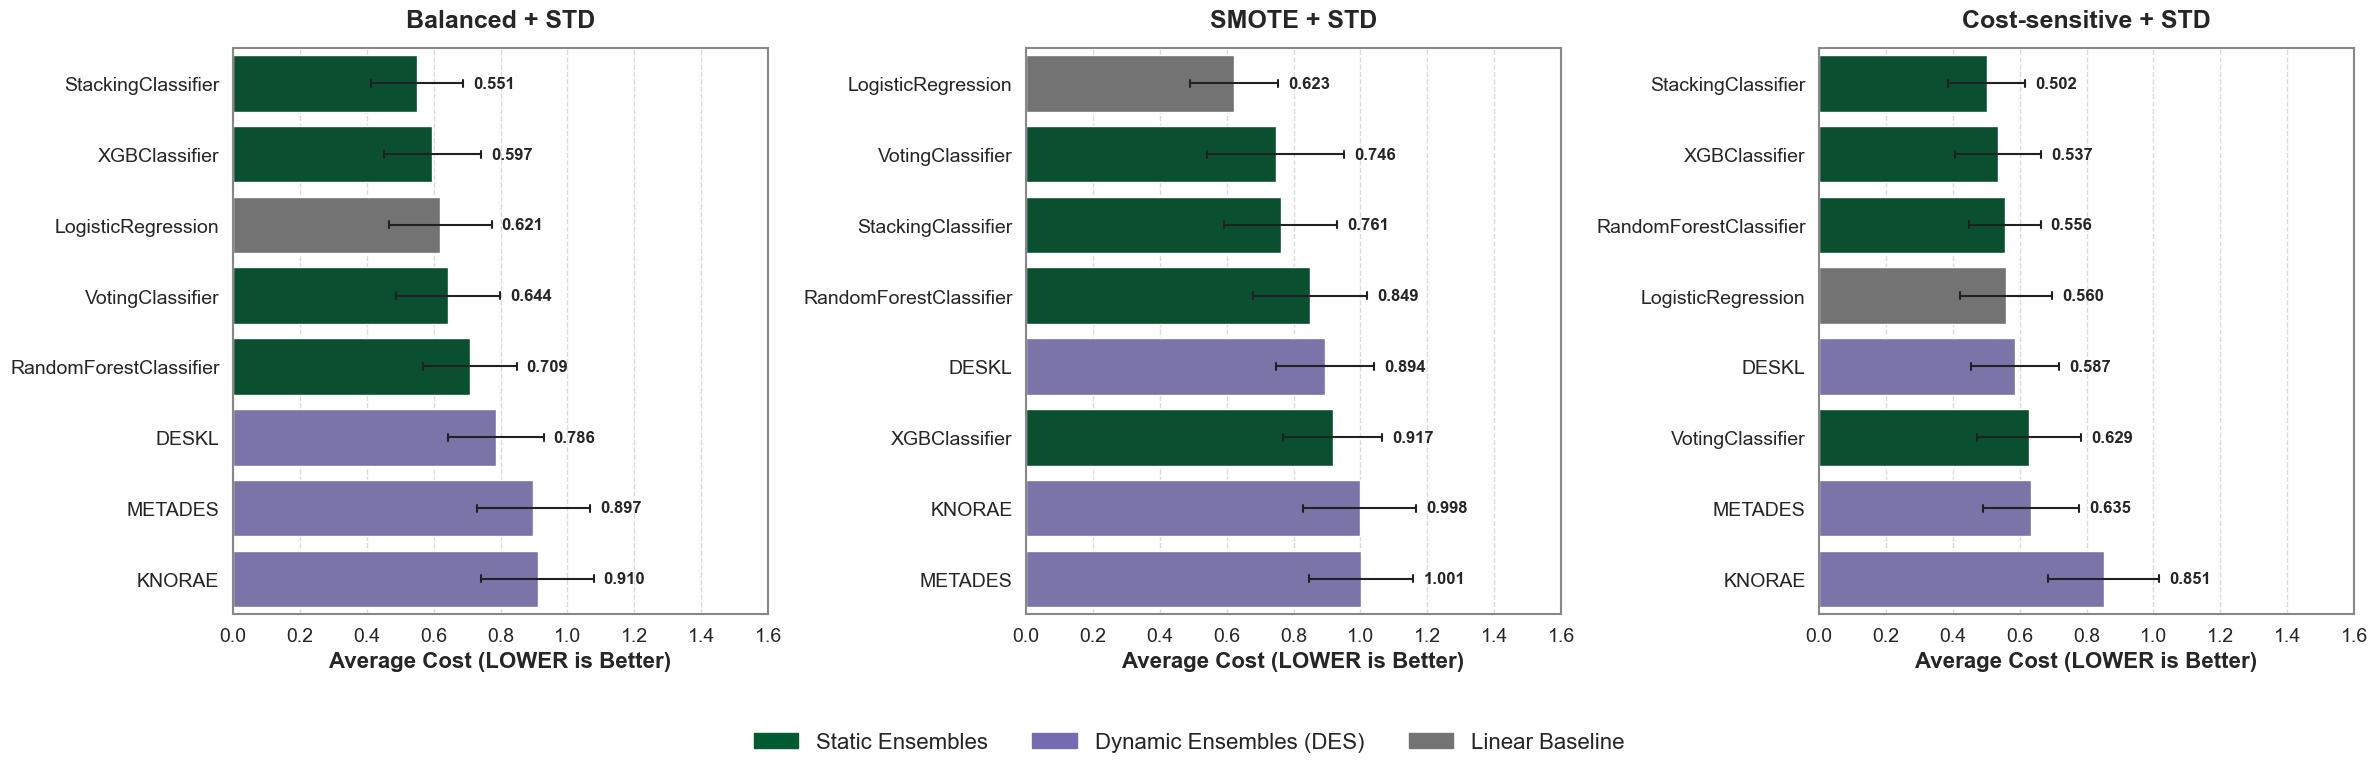

In [15]:
# Select the experiment to compare
experiments = {
    "csl_balanced__standard": "Balanced + STD",
    "smote_auto__standard": "SMOTE + STD",
    "csl_fp1_fn10__standard": "Cost-sensitive + STD"
}

# Filter and sort the dataframe
df_slide4 = generalization_df[generalization_df['experiment_name'].isin(experiments.keys())].copy()

# Map each model to its family
def assign_family(model_name):
    if model_name in ['StackingClassifier', 'XGBClassifier', 'RandomForestClassifier', 'VotingClassifier']:
        return 'Static Ensembles'
    elif model_name in ['DESKL', 'METADES', 'KNORAE']:
        return 'Dynamic Ensembles (DES)'
    else:
        return 'Linear Baseline' # LogisticRegression

df_slide4['model_family'] = df_slide4['model_no_alias'].apply(assign_family)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 8), sharey=False)

family_colors = {
    'Static Ensembles': '#005a32',           # Dark Green
    'Dynamic Ensembles (DES)': '#756bb1',    # Purple
    'Linear Baseline': '#737373'             # Grey
}

for i, (exp_key, exp_title) in enumerate(experiments.items()):
    ax = axes[i]
    df_exp = df_slide4[df_slide4['experiment_name'] == exp_key].copy()

    model_means = df_exp.groupby('model_no_alias')['average_cost'].mean().sort_values(ascending=True)
    model_order = model_means.index.tolist()

    sns.barplot(
        data=df_exp,
        x='average_cost',
        y='model_no_alias',
        hue='model_family',
        order=model_order,
        dodge=False,
        palette=family_colors,
        ax=ax,
        errorbar='sd',
        capsize=0.1,
        err_kws={'linewidth': 1.5, 'color': '#212121'}
    )

    ax.set_title(exp_title, fontweight="bold", pad=15)
    ax.set_xlabel("Average Cost (LOWER is Better)", fontweight="bold")
    ax.set_ylabel('')

    for idx, model in enumerate(model_order):
        mean_val = df_exp[df_exp['model_no_alias'] == model]['average_cost'].mean()
        std_val = df_exp[df_exp['model_no_alias'] == model]['average_cost'].std()

        ax.text(mean_val + std_val + 0.03, idx,
                f'{mean_val:.3f}',
                ha='left', va='center', fontweight='bold', fontsize=12)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    ax.yaxis.grid(False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)

    ax.set_xlim(0, 1.6)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout(rect=[0, 0.12, 1, 1])

handles = [plt.Rectangle((0,0),1,1, color=family_colors[label]) for label in family_colors.keys()]
fig.legend(handles, family_colors.keys(),
           loc="lower center", ncol=3, fontsize=16, frameon=False, bbox_to_anchor=(0.5, 0.02))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide4_std_settings_static_des_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

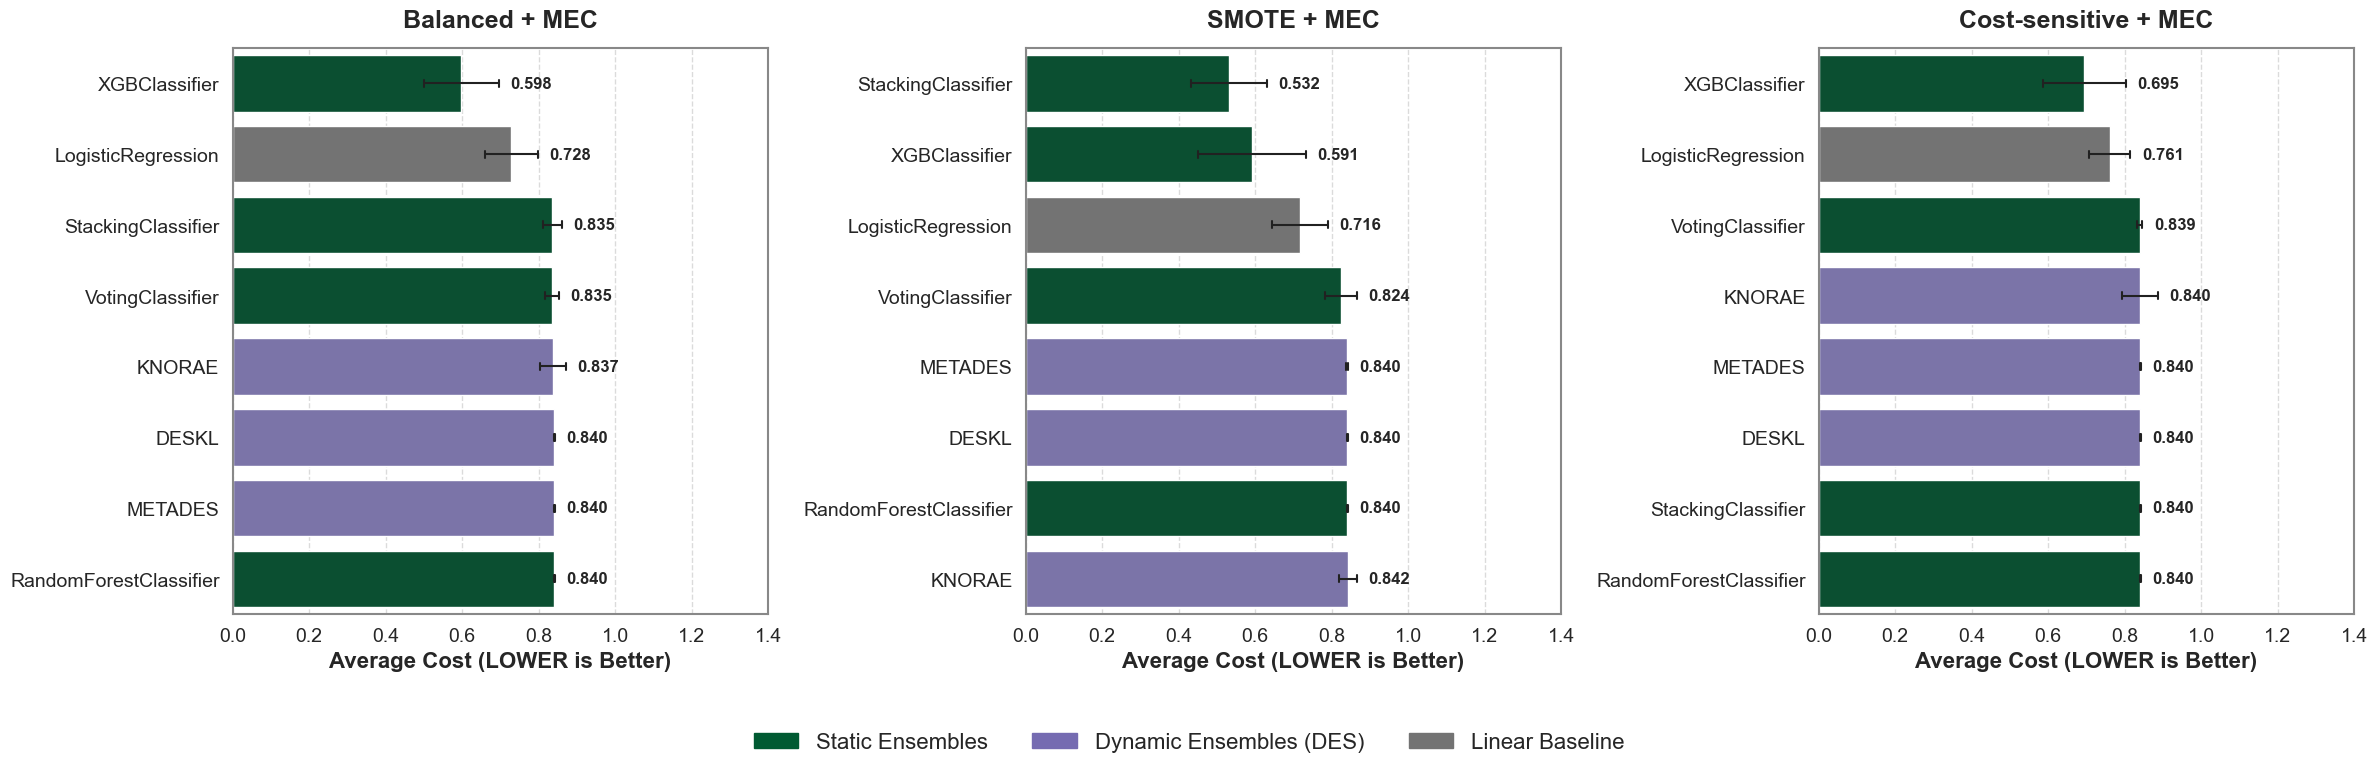

In [16]:
# Select the experiment to compare
experiments_mec = {
    "csl_balanced__mec_fp1_fn10": "Balanced + MEC",
    "smote_auto__mec_fp1_fn10": "SMOTE + MEC",
    "csl_fp1_fn10__mec_fp1_fn10": "Cost-sensitive + MEC"
}

# Filter and sort the dataframe
df_slide_mec = generalization_df[generalization_df['experiment_name'].isin(experiments_mec.keys())].copy()

# Map each model to its family
def assign_family(model_name):
    if model_name in ['StackingClassifier', 'XGBClassifier', 'RandomForestClassifier', 'VotingClassifier']:
        return 'Static Ensembles'
    elif model_name in ['DESKL', 'METADES', 'KNORAE']:
        return 'Dynamic Ensembles (DES)'
    else:
        return 'Linear Baseline' # LogisticRegression

df_slide_mec['model_family'] = df_slide_mec['model_no_alias'].apply(assign_family)

# Set the style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 8), sharey=False)

family_colors = {
    'Static Ensembles': '#005a32',           # Dark Green
    'Dynamic Ensembles (DES)': '#756bb1',    # Purple
    'Linear Baseline': '#737373'             # Grey
}

for i, (exp_key, exp_title) in enumerate(experiments_mec.items()):
    ax = axes[i]
    df_exp = df_slide_mec[df_slide_mec['experiment_name'] == exp_key].copy()

    model_means = df_exp.groupby('model_no_alias')['average_cost'].mean().sort_values(ascending=True)
    model_order = model_means.index.tolist()

    sns.barplot(
        data=df_exp,
        x='average_cost',
        y='model_no_alias',
        hue='model_family',
        order=model_order,
        dodge=False,
        palette=family_colors,
        ax=ax,
        errorbar='sd',
        capsize=0.1,
        err_kws={'linewidth': 1.5, 'color': '#212121'}
    )

    ax.set_title(exp_title, fontweight="bold", pad=15)
    ax.set_xlabel("Average Cost (LOWER is Better)", fontweight="bold")
    ax.set_ylabel('')

    for idx, model in enumerate(model_order):
        mean_val = df_exp[df_exp['model_no_alias'] == model]['average_cost'].mean()
        std_val = df_exp[df_exp['model_no_alias'] == model]['average_cost'].std()

        ax.text(mean_val + std_val + 0.03, idx,
                f'{mean_val:.3f}',
                ha='left', va='center', fontweight='bold', fontsize=12)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#888888')
        spine.set_linewidth(1.5)

    ax.yaxis.grid(False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)

    ax.set_xlim(0, 1.4)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout(rect=[0, 0.12, 1, 1])

handles = [plt.Rectangle((0,0),1,1, color=family_colors[label]) for label in family_colors.keys()]
fig.legend(handles, family_colors.keys(),
           loc="lower center", ncol=3, fontsize=16, frameon=False, bbox_to_anchor=(0.5, 0.02))

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide4_mec_settings_static_des_average_cost.png", dpi=300, bbox_inches="tight")
plt.show()

## Slide 5: The final overall and statistical results

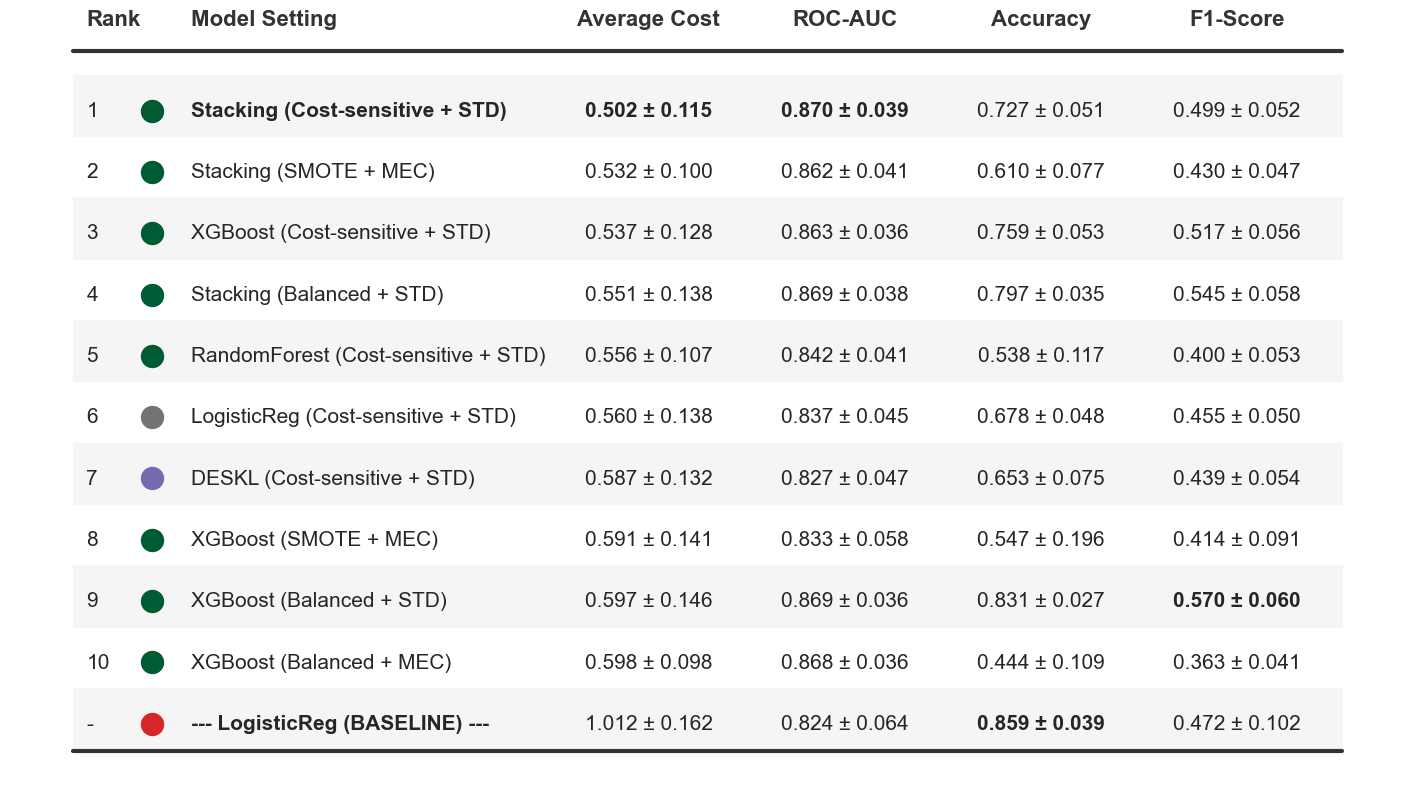

In [17]:
data = [
    {'Rank': 1, 'Model': 'Stacking (Cost-sensitive + STD)', 'Family': 'Static', 'Color': '#005a32', 'Cost': '0.502 ± 0.115', 'AUC': '0.870 ± 0.039', 'Acc': '0.727 ± 0.051', 'F1': '0.499 ± 0.052'},
    {'Rank': 2, 'Model': 'Stacking (SMOTE + MEC)', 'Family': 'Static', 'Color': '#005a32', 'Cost': '0.532 ± 0.100', 'AUC': '0.862 ± 0.041', 'Acc': '0.610 ± 0.077', 'F1': '0.430 ± 0.047'},
    {'Rank': 3, 'Model': 'XGBoost (Cost-sensitive + STD)', 'Family': 'Static', 'Color': '#005a32', 'Cost': '0.537 ± 0.128', 'AUC': '0.863 ± 0.036', 'Acc': '0.759 ± 0.053', 'F1': '0.517 ± 0.056'},
    {'Rank': 4, 'Model': 'Stacking (Balanced + STD)', 'Family': 'Static', 'Color': '#005a32', 'Cost': '0.551 ± 0.138', 'AUC': '0.869 ± 0.038', 'Acc': '0.797 ± 0.035', 'F1': '0.545 ± 0.058'},
    {'Rank': 5, 'Model': 'RandomForest (Cost-sensitive + STD)', 'Family': 'Static', 'Color': '#005a32', 'Cost': '0.556 ± 0.107', 'AUC': '0.842 ± 0.041', 'Acc': '0.538 ± 0.117', 'F1': '0.400 ± 0.053'},
    {'Rank': 6, 'Model': 'LogisticReg (Cost-sensitive + STD)', 'Family': 'Linear', 'Color': '#737373', 'Cost': '0.560 ± 0.138', 'AUC': '0.837 ± 0.045', 'Acc': '0.678 ± 0.048', 'F1': '0.455 ± 0.050'},
    {'Rank': 7, 'Model': 'DESKL (Cost-sensitive + STD)', 'Family': 'DES', 'Color': '#756bb1', 'Cost': '0.587 ± 0.132', 'AUC': '0.827 ± 0.047', 'Acc': '0.653 ± 0.075', 'F1': '0.439 ± 0.054'},
    {'Rank': 8, 'Model': 'XGBoost (SMOTE + MEC)', 'Family': 'Static', 'Color': '#005a32', 'Cost': '0.591 ± 0.141', 'AUC': '0.833 ± 0.058', 'Acc': '0.547 ± 0.196', 'F1': '0.414 ± 0.091'},
    {'Rank': 9, 'Model': 'XGBoost (Balanced + STD)', 'Family': 'Static', 'Color': '#005a32', 'Cost': '0.597 ± 0.146', 'AUC': '0.869 ± 0.036', 'Acc': '0.831 ± 0.027', 'F1': '0.570 ± 0.060'},
    {'Rank': 10,'Model': 'XGBoost (Balanced + MEC)', 'Family': 'Static', 'Color': '#005a32', 'Cost': '0.598 ± 0.098', 'AUC': '0.868 ± 0.036', 'Acc': '0.444 ± 0.109', 'F1': '0.363 ± 0.041'},
    {'Rank': '-', 'Model': '--- LogisticReg (BASELINE) ---', 'Family': 'Linear', 'Color': '#d62728', 'Cost': '1.012 ± 0.162', 'AUC': '0.824 ± 0.064', 'Acc': '0.859 ± 0.039', 'F1': '0.472 ± 0.102'}
]

df_table = pd.DataFrame(data)

# Set the style
fig, ax = plt.subplots(figsize=(18, 10))
ax.axis('off')

headers = ['Rank', '', 'Model Setting', 'Average Cost', 'ROC-AUC', 'Accuracy', 'F1-Score']
# X Pos:  Rank,   Dot,  Model,        Cost,  AUC,   Acc,   F1
x_pos =   [0.02,  0.07, 0.10,         0.45,  0.60,  0.75,  0.90]

for i, text in enumerate(headers):
    align = 'center' if i >= 3 else 'left'
    ax.text(x_pos[i], 0.95, text, fontweight='bold', fontsize=16, ha=align, color='#333333')

ax.plot([0.01, 0.98], [0.92, 0.92], lw=3, color='#333333')

y_start = 0.85
y_step = 0.072

for index, row in df_table.iterrows():
    y = y_start - (index * y_step)

    if index % 2 == 0:
        ax.add_patch(plt.Rectangle((0.01, y-0.03), 0.97, y_step, color='#f5f5f5', zorder=0))

    # 1. Rank
    ax.text(x_pos[0], y, str(row['Rank']), fontsize=15, ha='left', va='center')

    # 2. Color
    ax.scatter(x_pos[1], y, color=row['Color'], s=250, zorder=2)

    # 3. Model name
    name_weight = 'bold' if row['Rank'] == 1 or row['Rank'] == '-' else 'normal'
    ax.text(x_pos[2], y, row['Model'], fontsize=15, ha='left', va='center', fontweight=name_weight)

    # 4. Average Cost (Best is Index 0: 0.502)
    cost_weight = 'bold' if index == 0 else 'normal'
    ax.text(x_pos[3], y, row['Cost'], fontsize=15, ha='center', va='center', fontweight=cost_weight)

    # 5. ROC-AUC (Best is Index 0: 0.870)
    auc_weight = 'bold' if index == 0 else 'normal'
    ax.text(x_pos[4], y, row['AUC'], fontsize=15, ha='center', va='center', fontweight=auc_weight)

    # 6. Accuracy (Best is Index 10: 0.859)
    acc_weight = 'bold' if index == 10 else 'normal'
    ax.text(x_pos[5], y, row['Acc'], fontsize=15, ha='center', va='center', fontweight=acc_weight)

    # 7. F1-Score (Best is Index 8: 0.570)
    f1_weight = 'bold' if index == 8 else 'normal'
    ax.text(x_pos[6], y, row['F1'], fontsize=15, ha='center', va='center', fontweight=f1_weight)

ax.plot([0.01, 0.98], [y_start - (len(df_table) * y_step) + 0.04, y_start - (len(df_table) * y_step) + 0.04], lw=3, color='#333333')

plt.savefig(f"{FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR}/slide5_final_table_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
def compute_pairwise_corrected_resampled_ttest(
    df: pd.DataFrame,
    metric_name: str,
    n_train: int | float,
    n_test: int | float,
    save_path: Path,
    alpha: float = 0.05,
    heatmap_figsize: tuple[float, float] = (10, 8),
    ranking_figsize: tuple[float, float] = (14, 8),
    ranking_value_label_fontsize: float = 11,
) -> pd.DataFrame:
    """
    Compute ordered pairwise corrected resampled t-tests (Nadeau–Bengio) for a single metric and save outputs.

    This function performs an all-vs-all **ordered** pairwise comparison across models for one
    metric column. For each ordered pair (``Model_A``, ``Model_B``) with ``Model_A != Model_B``,
    it extracts the per-model metric vectors from ``df``, applies :func:`corrected_resampled_ttest`,
    and records the resulting t-statistic and p-value.

    The function also computes the per-model means and their difference (A − B), derives a
    significance flag based on ``alpha``, and assigns a qualitative label:

    - ``"Better"``: Model_A significantly outperforms Model_B (p < alpha and t-stat > 0)
    - ``"Worse"``:  Model_A significantly underperforms Model_B (p < alpha and t-stat < 0)
    - ``"No Diff"``: no statistically significant difference (p >= alpha)

    After computing all comparisons, the function saves a metric-specific CSV under ``save_path``
    and triggers two plots:
    - :func:`plot_significance_heatmap` (p-value heatmap), and
    - :func:`plot_ranking_with_significance` (ranked barplot with clique lines).

    Parameters
    ----------
    df : pandas.DataFrame
        Input results DataFrame. Must contain:
        - ``"model"``: model identifier, and
        - ``metric_name``: numeric column holding the metric scores to compare.

        The function sorts ``df`` in-place by ``"model"`` to enforce consistent model ordering.
    metric_name : str
        Metric column name to compare across models (e.g., ``"roc_auc"``, ``"f1"``).
        Must exist in ``df`` and be numeric.
    n_train : int or float
        Number of samples used for training in each resample/split. Forwarded to
        :func:`corrected_resampled_ttest`. Must be positive.
    n_test : int or float
        Number of samples used for testing in each resample/split. Forwarded to
        :func:`corrected_resampled_ttest`. Must be positive.
    save_path : pathlib.Path
        Output directory where the CSV and figures will be written. The directory must exist
        and be writable.
    alpha : float, default=0.05
        Significance threshold used to set ``is_significant`` and the ``result`` label.
        Must be in ``(0, 1)``.
    heatmap_figsize : tuple of float, default=(10, 8)
        Figure size passed to :func:`plot_significance_heatmap` as ``(width, height)``
        in inches.
    ranking_figsize : tuple of float, default=(14, 8)
        Figure size passed to :func:`plot_ranking_with_significance` as ``(width, height)``
        in inches.
    ranking_value_label_fontsize : float, default=11
        Font size passed to :func:`plot_ranking_with_significance` for the numeric value
        labels shown inside the bars.

    Returns
    -------
    pandas.DataFrame
        Pairwise comparison table with one row per **ordered** model pair (A, B), containing:

        - ``"Metric"``: the metric name (constant = ``metric_name``),
        - ``"Model_A"``, ``"Model_B"``: ordered model pair,
        - ``"Mean_Diff"``: mean(metric_A) − mean(metric_B),
        - ``"t-stat"``: corrected resampled t-statistic,
        - ``"p-value"``: two-tailed p-value,
        - ``"is_significant"``: boolean (p-value < alpha),
        - ``"result"``: categorical label in {``"Better"``, ``"Worse"``, ``"No Diff"``}.

    Raises
    ------
    KeyError
        If ``"model"`` or ``metric_name`` is not present in ``df``.
    ValueError
        If ``alpha`` is not in ``(0, 1)``, or if ``n_train``/``n_test`` are not positive.
    PermissionError
        If the CSV or figures cannot be written due to insufficient permissions.
    OSError
        For OS-related errors during file writing.

    Notes
    -----
    - The pairwise loop is **ordered**: A vs B and B vs A are both computed; self-comparisons
      are skipped.
    - Vectors are extracted as::

          vec_a = df[df["model"] == model_a][metric_name].values
          vec_b = df[df["model"] == model_b][metric_name].values

      If ``len(vec_a) != len(vec_b)``, the pair is skipped and a warning is printed. This
      typically indicates missing rows for one model (e.g., missing folds/iterations).
    - Results are saved as::

          corrected_resampled_ttest_<metric_name>.csv

    - Plots are generated via::

          plot_significance_heatmap(
              df_comparisons,
              metric_name,
              save_path,
              figsize=heatmap_figsize,
          )
          plot_ranking_with_significance(
              df,
              df_comparisons,
              metric_name,
              save_path,
              figsize=ranking_figsize,
              value_label_fontsize=ranking_value_label_fontsize,
          )

    Examples
    --------
    >>> import pandas as pd
    >>> from pathlib import Path
    >>> df = pd.DataFrame(
    ...     {
    ...         "model": ["A", "A", "B", "B"],
    ...         "roc_auc": [0.91, 0.89, 0.93, 0.92],
    ...     }
    ... )
    >>> out = compute_pairwise_corrected_resampled_ttest(
    ...     df=df,
    ...     metric_name="roc_auc",
    ...     n_train=20000,
    ...     n_test=5000,
    ...     save_path=Path("."),
    ...     alpha=0.05,
    ...     heatmap_figsize=(10, 8),
    ...     ranking_figsize=(14, 8),
    ...     ranking_value_label_fontsize=11,
    ... )
    >>> {"Model_A", "Model_B", "p-value", "result"}.issubset(out.columns)
    True
    """

    print(
        f"\n{'=' * 80}\nCORRECTED RESAMPLED t-TEST ANALYSIS (Pairwise): {metric_name.upper()}\n{'=' * 80}"
    )

    # 1. Sort Models for consistent ordering
    df.sort_values(by=["model"], inplace=True)
    unique_models = df["model"].unique()

    comparison_records = []

    # 2. Compute Statistics (All vs All)
    for model_a in unique_models:
        for model_b in unique_models:
            if model_a == model_b:
                continue

            # Extract vectors for the specific metric
            vec_a = df[df["model"] == model_a][metric_name].values
            vec_b = df[df["model"] == model_b][metric_name].values

            # Sanity check
            if len(vec_a) != len(vec_b):
                print(f"Warning: Size mismatch {model_a} vs {model_b}")
                continue

            # Perform Statistical Test
            t_stat, p_val = corrected_resampled_ttest(vec_a, vec_b, n_train, n_test)

            # Calculate Means (for printing and magnitude)
            mean_a = np.mean(vec_a)
            mean_b = np.mean(vec_b)
            mean_diff = mean_a - mean_b

            # Determine Relationship Label
            is_significant = p_val < alpha

            if is_significant and t_stat > 0:
                relationship = "Better"  # A is significantly better than B
            elif is_significant and t_stat < 0:
                relationship = "Worse"  # A is significantly worse than B
            else:
                relationship = "No Diff"  # Statistical Tie

            # --- DETAILED PRINTING ---
            sig_label = "Statistically SIGNIFICANT" if is_significant else "NOT significant"
            print(f"Comparing '{model_a}' (mean={mean_a:.3f}) vs '{model_b}' (mean={mean_b:.3f})")
            print(f"  p-value: {p_val:.4f} (t={t_stat:.4f}) -> {sig_label}")
            print("-" * 80)

            comparison_records.append(
                {
                    "Metric": metric_name,
                    "Model_A": model_a,
                    "Model_B": model_b,
                    "Mean_Diff": mean_diff,
                    "t-stat": t_stat,
                    "p-value": p_val,
                    "is_significant": is_significant,
                    "result": relationship,
                }
            )

    # 3. Create DataFrame
    df_comparisons = pd.DataFrame(comparison_records)

    # 4. Save Single Metric CSV
    csv_filename = f"corrected_resampled_ttest_{metric_name}.csv"
    df_comparisons.to_csv(save_path / csv_filename, index=False)

    # 5. Generate Visualization (Heatmap)
    plot_significance_heatmap(
        df_comparisons,
        metric_name,
        save_path,
        figsize=heatmap_figsize,
    )
    plot_ranking_with_significance(
        df,
        df_comparisons,
        metric_name,
        save_path,
        figsize=ranking_figsize,
        value_label_fontsize=ranking_value_label_fontsize,
    )

    return df_comparisons


def plot_significance_heatmap(
    df_comparisons: pd.DataFrame,
    metric_name: str,
    save_path: Path,
    figsize: tuple[float, float] = (10, 8),
) -> None:
    """
    Plot a lower-triangular pairwise significance heatmap for a given metric.

    This function filters a pairwise-comparisons DataFrame to the requested metric,
    pivots the filtered rows into a p-value matrix (Model A × Model B), fills missing
    pairs with ``1.0`` (treated as non-significant), and renders a significance heatmap
    via :func:`scikit_posthocs.sign_plot`. The resulting figure is saved under
    ``save_path`` with a filename that includes the metric name.

    Parameters
    ----------
    df_comparisons : pandas.DataFrame
        Pairwise statistical comparison results. The DataFrame must include at least
        the following columns:

        - ``"Metric"``: metric identifier used to select rows for plotting.
        - ``"Model_A"``: row model label in the p-value matrix.
        - ``"Model_B"``: column model label in the p-value matrix.
        - ``"p-value"``: p-value associated with the (Model_A, Model_B) comparison.
    metric_name : str
        Metric name to plot. Must match one of the values in ``df_comparisons["Metric"]``.
    save_path : pathlib.Path
        Output directory where the heatmap image will be written. The function assumes the
        directory exists and is writable.
    figsize : tuple of float, default=(10, 8)
        Figure size passed to ``plt.figure(figsize=...)`` as ``(width, height)`` in inches.

    Returns
    -------
    None
        Side effects only (figure generation and file output).

    Raises
    ------
    KeyError
        If required columns (``"Metric"``, ``"Model_A"``, ``"Model_B"``, or ``"p-value"``)
        are missing from ``df_comparisons``.
    ValueError
        If no rows match the requested ``metric_name`` and the pivoted matrix is empty.
    PermissionError
        If the output image cannot be written due to insufficient permissions.
    OSError
        For OS-related errors during file writing.

    Notes
    -----
    - Rows are filtered as::

          df_metric = df_comparisons[df_comparisons["Metric"] == metric_name].copy()

    - The p-value matrix is created as::

          p_matrix = df_metric.pivot(index="Model_A", columns="Model_B", values="p-value")
          p_matrix = p_matrix.fillna(1.0)

      Missing comparisons are filled with ``1.0`` so they appear as non-significant.
    - The plot is produced using a user-defined categorical colormap list and styling
      options forwarded to :func:`scikit_posthocs.sign_plot` via ``heatmap_args``.
    - The figure title includes the metric name and indicates the corrected resampled
      t-test context.
    - The saved filename is::

          corrected_resampled_ttest_<metric_name>_heatmap.png

    Examples
    --------
    >>> import pandas as pd
    >>> from pathlib import Path
    >>> df_comp = pd.DataFrame(
    ...     {
    ...         "Metric": ["roc_auc", "roc_auc"],
    ...         "Model_A": ["A", "A"],
    ...         "Model_B": ["B", "C"],
    ...         "p-value": [0.03, 0.20],
    ...     }
    ... )
    >>> plot_significance_heatmap(
    ...     df_comparisons=df_comp,
    ...     metric_name="roc_auc",
    ...     save_path=Path("."),
    ...     figsize=(10, 8),
    ... )
    """

    # 1. FILTER: Select only the rows for the current metric
    df_metric = df_comparisons[df_comparisons["Metric"] == metric_name].copy()

    # 2. Pivot to get the P-Value Matrix
    p_matrix = df_metric.pivot(index="Model_A", columns="Model_B", values="p-value")

    # 3. Fill NaNs with 1.0 (non-significant) initially to handle missing pairs
    p_matrix = p_matrix.fillna(1.0)

    # 4. Plot using scikit-posthocs
    plt.figure(figsize=figsize)

    # Define Colormap:
    # 1 (White), 0.05, 0.01, 0.001 (Blues/Reds)
    cmap = ["1", "#fb6a4a", "#08306b", "#4292c6", "#c6dbef"]

    heatmap_args = {
        "cmap": cmap,
        "linewidths": 0.5,  # Slightly thicker lines for clarity
        "linecolor": "0.9",  # Light gray grid lines
        "clip_on": False,
        "square": True,  # Force square cells
        # [x, y, width, height] in figure coordinate system
        # Moved x to 1.02 to place it outside the plot area
        "cbar_ax_bbox": [0.90, 0.35, 0.03, 0.3],
    }

    # Plot
    sp.sign_plot(p_matrix, **heatmap_args)

    #plt.suptitle(
    #    f"Pairwise Significance: {metric_name.upper()}\n(Corrected Resampled t-test)",
    #    fontweight="bold",
    #)

    # Adjust layout to accommodate the external legend
    plt.subplots_adjust(right=0.85)

    plt.savefig(
        save_path / f"corrected_resampled_ttest_{metric_name}_heatmap.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()


def plot_ranking_with_significance(
    df_raw: pd.DataFrame,
    df_comparisons: pd.DataFrame,
    metric_name: str,
    save_path: Path,
    greater_is_better: bool = True,
    alpha: float = 0.05,
    figsize: tuple[float, float] = (14, 8),
    value_label_fontsize: float = 11,
) -> None:
    """
    Plot a mean±std model ranking horizontal barplot and overlay statistical-tie cliques from pairwise tests.

    This function ranks models by the mean value of ``metric_name`` computed from ``df_raw``,
    draws a horizontal barplot with standard-deviation error bars, and overlays vertical “clique” lines
    indicating groups of models that are not significantly different according to the pairwise
    p-values in ``df_comparisons`` (typically produced by corrected resampled t-tests).

    Clique construction
    -------------------
    For the requested ``metric_name``, the function builds an undirected graph where each node
    is a model and an edge is added between two models when their pairwise comparison is
    *not significant* (``p-value >= alpha``). Maximal cliques of this graph (size > 1) are then
    converted into y-axis index intervals and drawn as vertical lines to the right of the bars. Nested
    clique intervals (subsets contained in larger intervals) are removed to reduce visual clutter.

    Parameters
    ----------
    df_raw : pandas.DataFrame
        Raw per-fold/per-iteration results used to compute mean and standard deviation per model.
        Must contain at least:
        - ``"model"``: model identifier, and
        - ``metric_name``: numeric column with the metric values to rank/plot.
    df_comparisons : pandas.DataFrame
        Pairwise comparison results containing p-values for the given metric. Must contain:
        - ``"Metric"``: metric identifier (used to filter rows for ``metric_name``),
        - ``"Model_A"`` and ``"Model_B"``: model labels, and
        - ``"p-value"``: p-value for each ordered pair.
    metric_name : str
        Metric column name used for ranking and plotting (e.g., ``"roc_auc"``, ``"f1"``).
        Must exist in ``df_raw`` and be numeric.
    save_path : pathlib.Path
        Output directory where the figure is saved. The directory must exist and be writable.
    greater_is_better : bool, default=True
        Sorting direction:
        - ``True``  → sort models by descending mean (best first),
        - ``False`` → sort models by ascending mean (best first), for loss-like metrics.
    alpha : float, default=0.05
        Significance threshold used to define non-significant edges (statistical ties) in the
        clique graph. Edges are added when ``p-value >= alpha``.
    figsize : tuple of float, default=(14, 8)
        Figure size passed to ``plt.figure(figsize=...)`` as ``(width, height)`` in inches.
    value_label_fontsize : float, default=11
        Font size used for the numeric value labels added inside the bars via ``ax.text(...)``.

    Returns
    -------
    None
        Side effects only (figure generation and file output).
    """

    # --- STEP 1: Calculate Statistics ---
    stats = df_raw.groupby("model")[metric_name].agg(["mean", "std"])

    # --- STEP 2: Sort Models by Performance ---
    # If greater_is_better=True (Accuracy): Sort Descending (Highest on top)
    # If greater_is_better=False (RMSE): Sort Ascending (Lowest on top)
    stats = stats.sort_values("mean", ascending=not greater_is_better)

    sorted_models = stats.index.tolist()

    # --- STEP 3: Identify Cliques (Statistical Ties) ---
    # Create a graph where Nodes = Models
    G = nx.Graph()
    G.add_nodes_from(sorted_models)

    # Filter only relevant comparisons
    df_metric_comp = df_comparisons[df_comparisons["Metric"] == metric_name]

    # Add an edge between models if they are NOT significantly different
    for _, row in df_metric_comp.iterrows():
        if row["p-value"] >= alpha:
            G.add_edge(row["Model_A"], row["Model_B"])

    # Find groups of models that are all connected (Maximal Cliques)
    cliques = list(nx.find_cliques(G))

    # Convert model names to their integer Y-axis positions
    clique_intervals = []
    for clq in cliques:
        if len(clq) > 1:
            # Find where these models sit in our sorted list
            indices = [sorted_models.index(m) for m in clq]
            # We only need the span: from Index X to Index Y
            clique_intervals.append((min(indices), max(indices)))

    # Cleanup: Sort by length so we draw smaller groups first (looks better)
    # Filter out subsets (e.g., if A-B-C is a group, ignore A-B)
    clique_intervals.sort(key=lambda x: x[1] - x[0], reverse=True)

    final_cliques = []
    for interval in clique_intervals:
        is_subset = False
        for other in final_cliques:
            if interval[0] >= other[0] and interval[1] <= other[1]:
                is_subset = True
                break
        if not is_subset:
            final_cliques.append(interval)

    # --- STEP 4: Plotting ---
    plt.figure(figsize=figsize)
    sns.set_style("whitegrid")

    # A. Dynamic Palette Generation based on Model Family Narrative
    custom_palette = {}
    for m in sorted_models:
        m_lower = str(m).lower()
        if "baseline" in m_lower:
            custom_palette[m] = "#d62728"  # Red for Absolute Baseline
        elif "logistic" in m_lower or "linear" in m_lower:
            custom_palette[m] = "#737373"  # Gray for Logistic Regression (optimized)
        elif any(des in m_lower for des in ["deskl", "metades", "knorae", "dynamic"]):
            custom_palette[m] = "#756bb1"  # Purple for Dynamic Ensembles (DES)
        else:
            custom_palette[m] = "#005a32"  # Green for Static Ensembles (Stacking, XGBoost, etc.)

    # B. Draw the Barplot (Swapped X and Y)
    # We use 'order=sorted_models' to force the Best->Worst arrangement (Top to Bottom)
    ax = sns.barplot(
        data=df_raw,
        x=metric_name,
        y="model",
        hue="model",
        palette=custom_palette,
        errorbar="sd",
        order=sorted_models,
        capsize=0.1,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.85,
        legend=False,
    )

    # C. Add Text Labels (Adjusted for Horizontal orientation)
    for i, model in enumerate(sorted_models):
        mean_val = stats.loc[model, "mean"]
        ax.text(
            0.05,  # Fixed position at the left base of the horizontal bar
            i,     # Y-axis position
            f"{mean_val:.3f}",
            color="black",
            ha="left",    # Left-aligned
            va="center",  # Centered vertically
            fontweight="bold",
            fontsize=value_label_fontsize,
            rotation=0,   # Set to 0 to read normally left-to-right
        )

    # D. Draw Clique Lines (Adjusted for Vertical lines on the right side)
    # Calculate starting width (right of the longest bar + error)
    max_width = (stats["mean"] + stats["std"]).max()
    x_step = max_width * 0.05  # Space between vertical lines
    current_x = max_width + x_step

    # Draw shortest cliques closer, longest cliques further to the right
    final_cliques.sort(key=lambda x: x[1] - x[0])

    for start_idx, end_idx in final_cliques:
        # Draw Vertical Line
        plt.plot(
            [current_x, current_x],
            [start_idx, end_idx],
            color="#333333",
            linewidth=2,
            marker="_",   # Horizontal caps on the vertical lines
            markersize=10,
        )
        current_x += x_step

    # E. Final Polish
    # plt.title(f"Model Ranking & Significance: {metric_name.upper()}", fontweight="bold", pad=20)
    plt.xlabel(f"{metric_name.upper()}\n(Mean ± Std Dev)", fontweight="bold")
    plt.ylabel("Model", fontweight="bold")

    # Adjust ticks for readability
    plt.yticks(fontsize=16)

    if metric_name != "average_cost":
        plt.xticks(np.arange(0, 1.1, 0.2))

    plt.xlim(0, current_x + x_step)  # Extend X-axis to fit the vertical clique lines
    plt.tight_layout()

    # Save Figure
    out_file = save_path / f"corrected_resampled_ttest_{metric_name}_barplot_significance.png"
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()



CORRECTED RESAMPLED t-TEST ANALYSIS (Pairwise): AVERAGE_COST
Comparing 'DESKL (Cost-sensitive + STD)' (mean=0.587) vs 'LogisticRegression (Baseline)' (mean=1.011)
  p-value: 0.0000 (t=-5.7904) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'DESKL (Cost-sensitive + STD)' (mean=0.587) vs 'LogisticRegression (Cost-sensitive + STD)' (mean=0.560)
  p-value: 0.6115 (t=0.5096) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'DESKL (Cost-sensitive + STD)' (mean=0.587) vs 'RandomForestClassifier (Cost-sensitive + STD)' (mean=0.556)
  p-value: 0.5732 (t=0.5653) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'DESKL (Cost-sensitive + STD)' (mean=0.587) vs 'StackingClassifier (Balanced + STD)' (mean=0.551)
  p-value: 0.5673 (t=0.5740) -> NOT significant
--------------------------------------------------

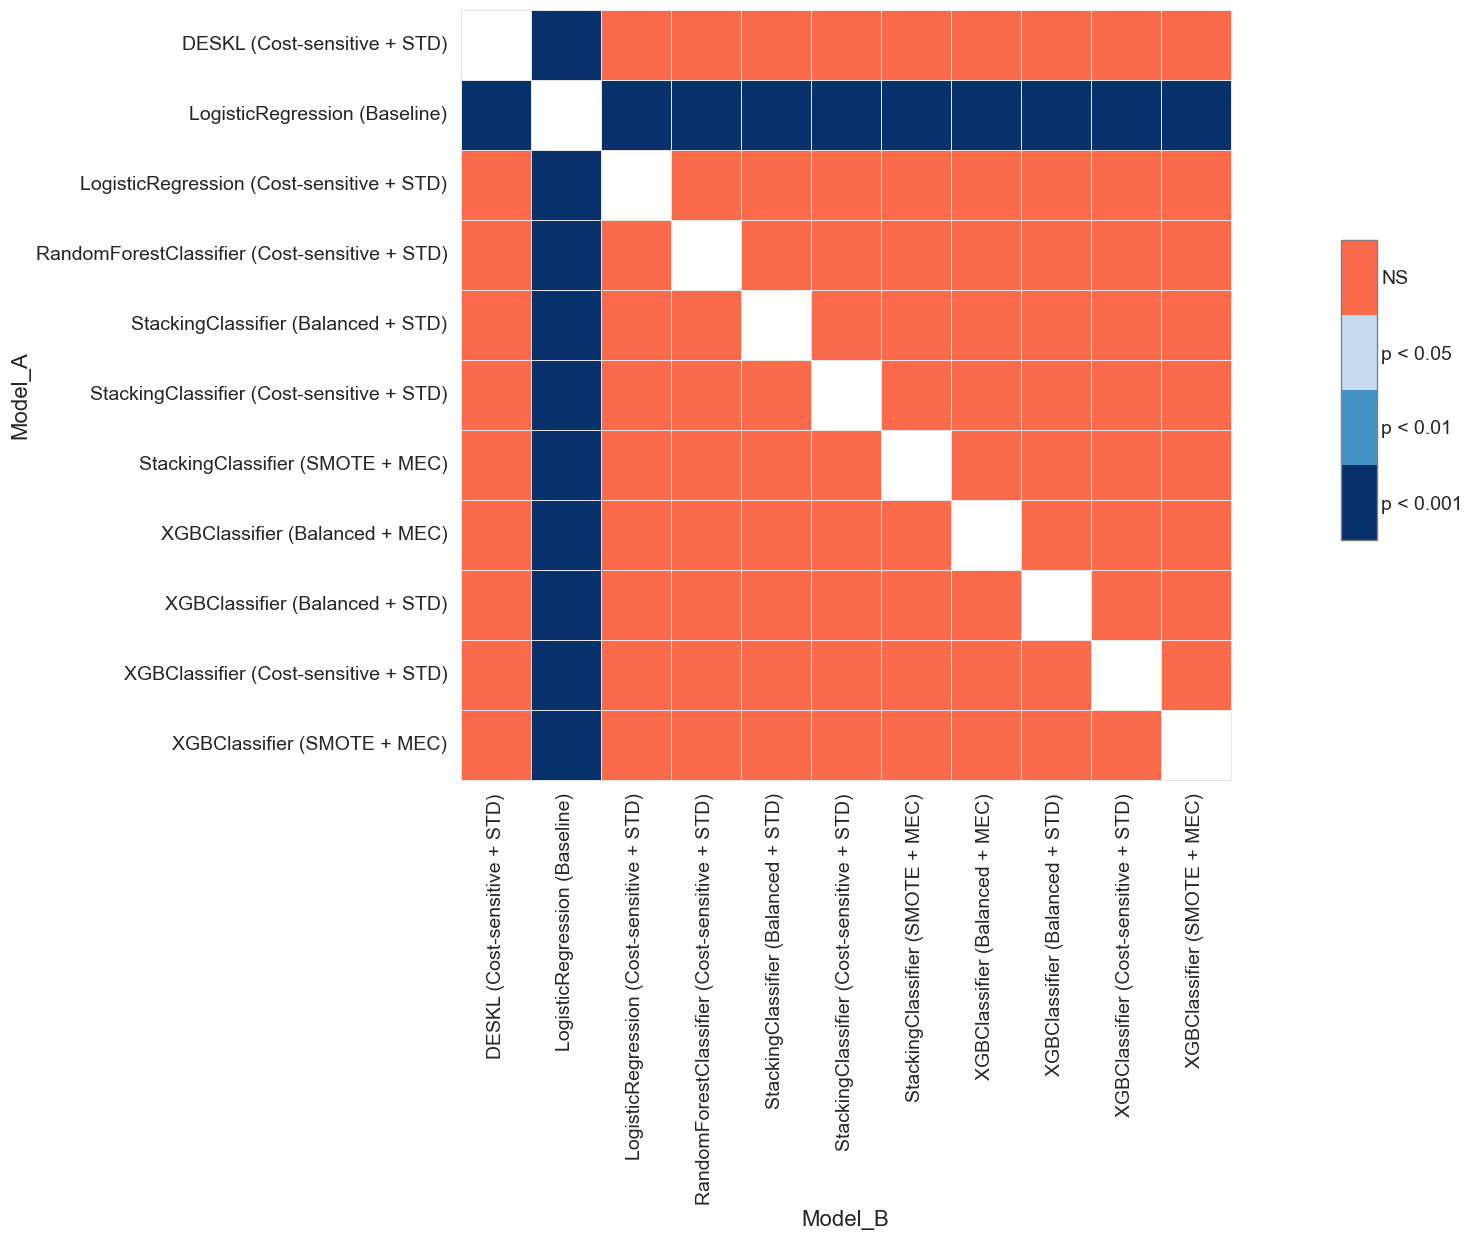

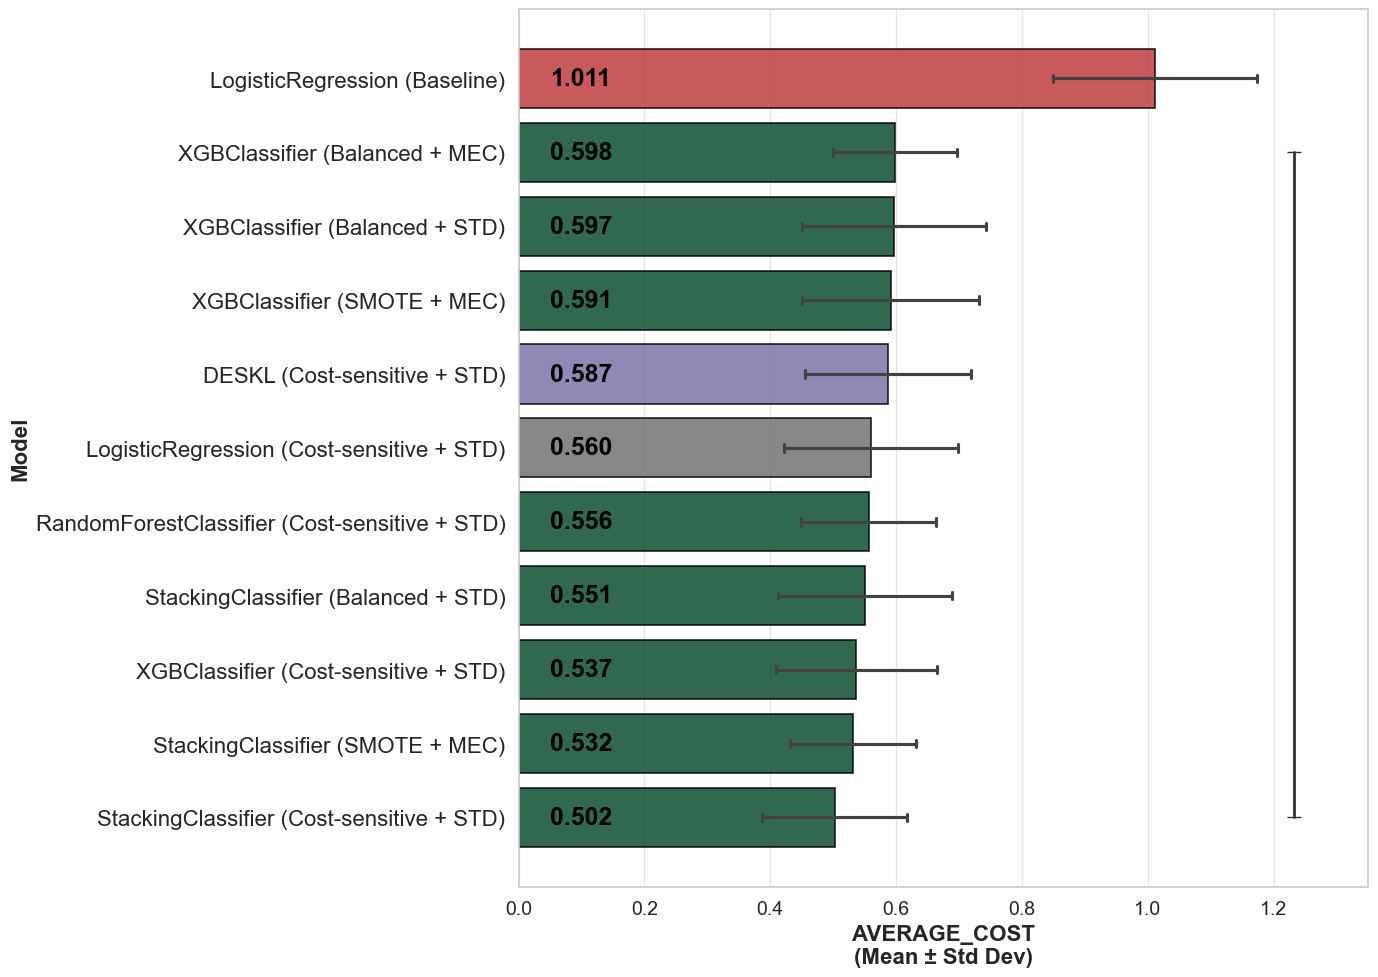

In [19]:
target_configurations = [
    ('StackingClassifier', 'csl_fp1_fn10__standard'),
    ('StackingClassifier', 'smote_auto__mec_fp1_fn10'),
    ('XGBClassifier', 'csl_fp1_fn10__standard'),
    ('StackingClassifier', 'csl_balanced__standard'),
    ('RandomForestClassifier', 'csl_fp1_fn10__standard'),
    ('LogisticRegression', 'csl_fp1_fn10__standard'),
    ('DESKL', 'csl_fp1_fn10__standard'),
    ('XGBClassifier', 'smote_auto__mec_fp1_fn10'),
    ('XGBClassifier', 'csl_balanced__standard'),
    ('XGBClassifier', 'csl_balanced__mec_fp1_fn10'),
    ('LogisticRegression', 'baseline__standard') # Baseline assoluta
]

mask = generalization_df.apply(
    lambda row: (row['model_no_alias'], row['experiment_name']) in target_configurations,
    axis=1
)
filtered_generalization_df = generalization_df[mask].copy()

metrics_to_analyze = ['average_cost']
pairwise_frames = []

for metric in metrics_to_analyze:
    report = compute_pairwise_corrected_resampled_ttest(
        df=filtered_generalization_df,
        metric_name=metric,
        n_train=0.9,
        n_test=0.1,
        save_path=FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR,
        heatmap_figsize=(12, 10),
        ranking_figsize=(14, 10),
        ranking_value_label_fontsize=18,
    )

    if report is not None:
        pairwise_frames.append(report)

# --- Aggregate & Save Master CSV ---
if pairwise_frames:
    # Concatenate all metric-specific dataframes vertically (stacking rows)
    final_comparisons_df = pd.concat(pairwise_frames, axis=0)
    final_csv_path = FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR / "corrected_resampled_ttest_top10_baseline.csv"
    final_comparisons_df.to_csv(final_csv_path, index=False)
else:
    print("No pairwise comparisons were generated.")


CORRECTED RESAMPLED t-TEST ANALYSIS (Pairwise): AVERAGE_COST
Comparing 'DESKL (Cost-sensitive + STD)' (mean=0.587) vs 'LogisticRegression (Balanced + MEC)' (mean=0.728)
  p-value: 0.0098 (t=-2.6341) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'DESKL (Cost-sensitive + STD)' (mean=0.587) vs 'LogisticRegression (Balanced + STD)' (mean=0.621)
  p-value: 0.6541 (t=-0.4494) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'DESKL (Cost-sensitive + STD)' (mean=0.587) vs 'LogisticRegression (Baseline)' (mean=1.011)
  p-value: 0.0000 (t=-5.8577) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'DESKL (Cost-sensitive + STD)' (mean=0.587) vs 'LogisticRegression (Cost-sensitive + STD)' (mean=0.560)
  p-value: 0.6782 (t=0.4162) -> NOT significant
------------------------------------------------

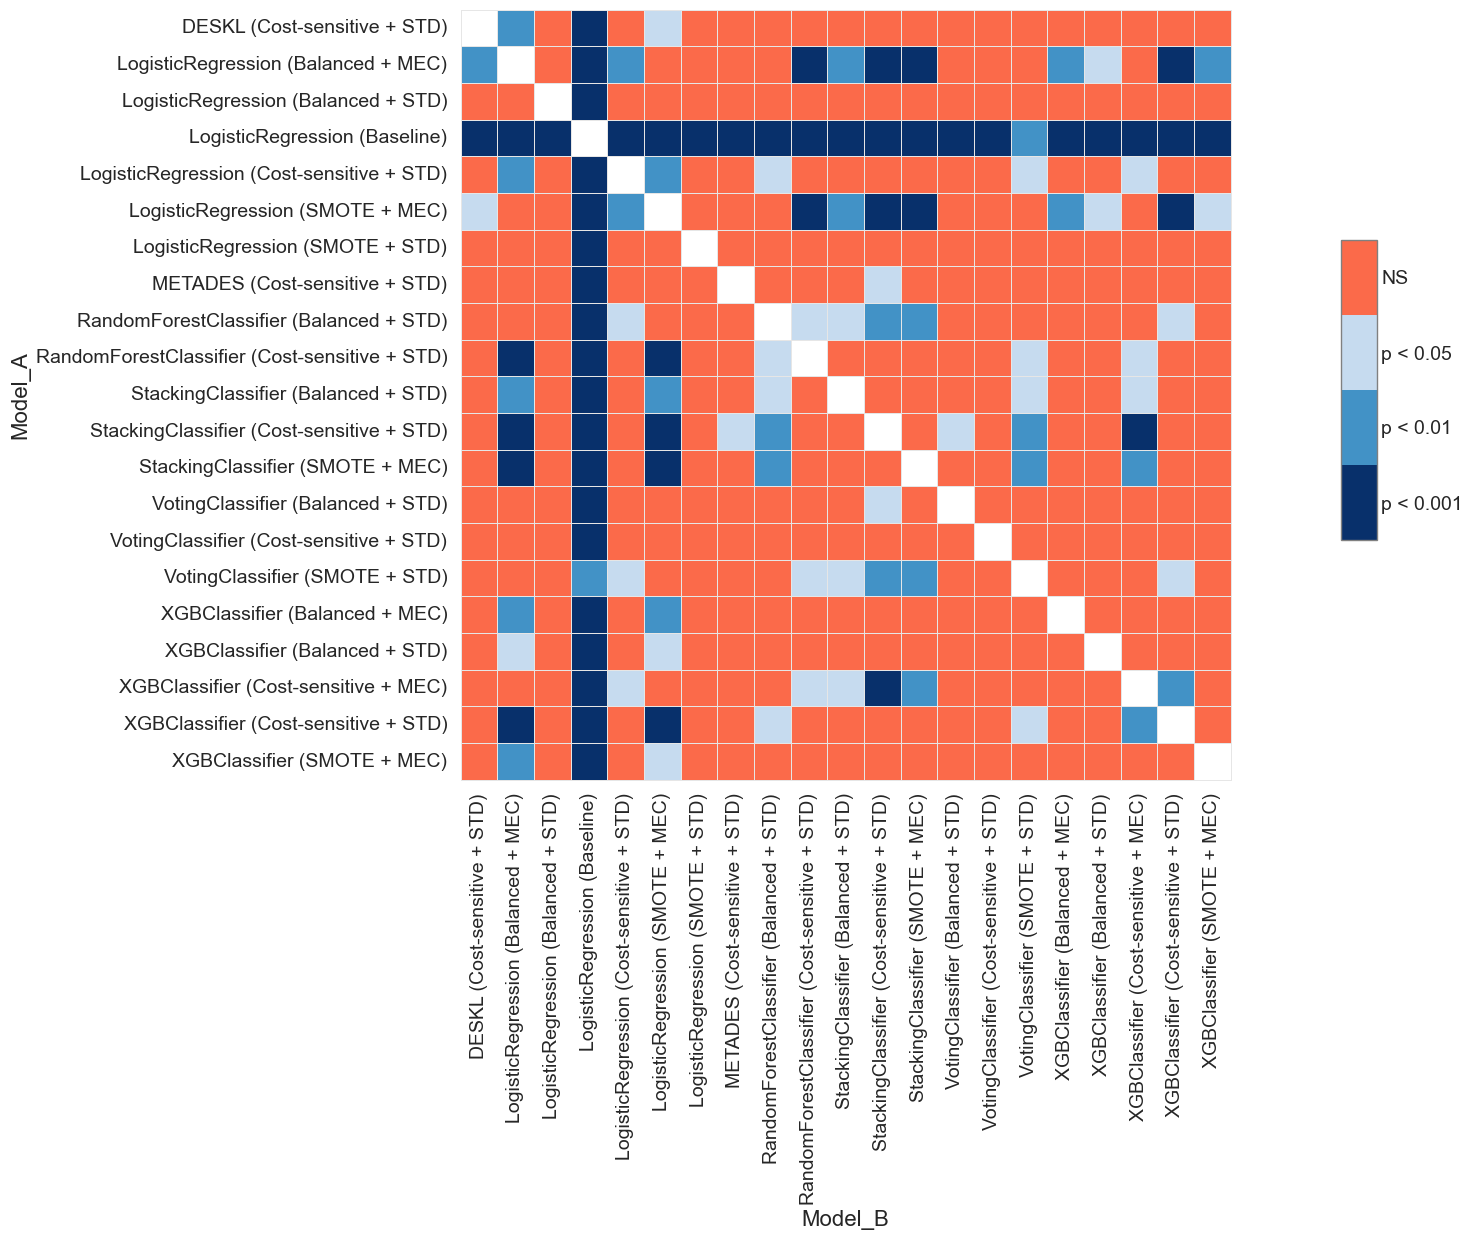

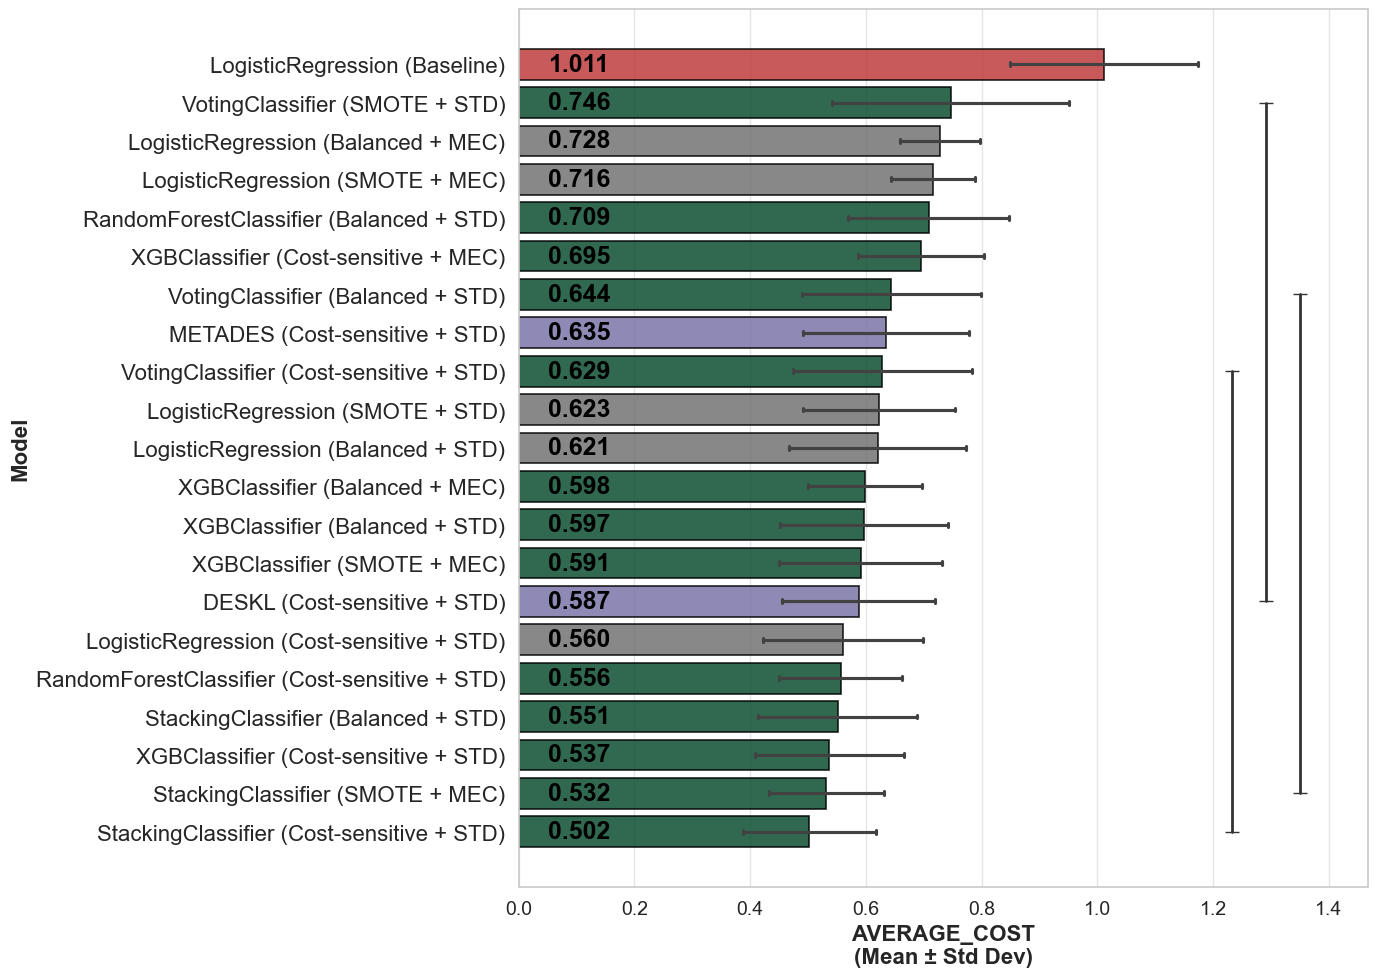

In [20]:
target_configurations = [
    ('StackingClassifier', 'csl_fp1_fn10__standard'),       # 1
    ('StackingClassifier', 'smote_auto__mec_fp1_fn10'),     # 2
    ('XGBClassifier', 'csl_fp1_fn10__standard'),            # 3
    ('StackingClassifier', 'csl_balanced__standard'),       # 4
    ('RandomForestClassifier', 'csl_fp1_fn10__standard'),   # 5
    ('LogisticRegression', 'csl_fp1_fn10__standard'),       # 6
    ('DESKL', 'csl_fp1_fn10__standard'),                    # 7
    ('XGBClassifier', 'smote_auto__mec_fp1_fn10'),          # 8
    ('XGBClassifier', 'csl_balanced__standard'),            # 9
    ('XGBClassifier', 'csl_balanced__mec_fp1_fn10'),        # 10
    ('LogisticRegression', 'csl_balanced__standard'),       # 11
    ('LogisticRegression', 'smote_auto__standard'),         # 12
    ('VotingClassifier', 'csl_fp1_fn10__standard'),         # 13
    ('METADES', 'csl_fp1_fn10__standard'),                  # 14
    ('VotingClassifier', 'csl_balanced__standard'),         # 15
    ('XGBClassifier', 'csl_fp1_fn10__mec_fp1_fn10'),        # 16
    ('RandomForestClassifier', 'csl_balanced__standard'),   # 17
    ('LogisticRegression', 'smote_auto__mec_fp1_fn10'),     # 18
    ('LogisticRegression', 'csl_balanced__mec_fp1_fn10'),   # 19
    ('VotingClassifier', 'smote_auto__standard'),           # 20
    ('LogisticRegression', 'baseline__standard')            # --- BASELINE ---
]

mask = generalization_df.apply(
    lambda row: (row['model_no_alias'], row['experiment_name']) in target_configurations,
    axis=1
)
filtered_generalization_df = generalization_df[mask].copy()

metrics_to_analyze = ['average_cost']
pairwise_frames = []

for metric in metrics_to_analyze:
    report = compute_pairwise_corrected_resampled_ttest(
        df=filtered_generalization_df,
        metric_name=metric,
        n_train=0.9,
        n_test=0.1,
        save_path=FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR,
        heatmap_figsize=(12, 10),
        ranking_figsize=(14, 10),
        ranking_value_label_fontsize=18,
    )

    if report is not None:
        pairwise_frames.append(report)

# --- Aggregate & Save Master CSV ---
if pairwise_frames:
    # Concatenate all metric-specific dataframes vertically (stacking rows)
    final_comparisons_df = pd.concat(pairwise_frames, axis=0)
    final_csv_path = FIGURES_EXP_SCHEMA_COMPARISON_PRESENTATION_DIR / "corrected_resampled_ttest_top20_baseline.csv"
    final_comparisons_df.to_csv(final_csv_path, index=False)
else:
    print("No pairwise comparisons were generated.")